# Exercise 3: Time series with ARIMA

## Do not start the exercise until you fully understand the submission guidelines.

- The homework assignments are executed automatically.
- Failure to comply with the following instructions will result in a significant penalty.
- Appeals regarding your failure to read these instructions will be denied.
- Kind reminder: the homework assignments contribute 60% of the final grade.

## Read the following instructions carefully:

1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. Some calculations in this exercise may take several minutes when implemented efficiently, and might take much longer otherwise. Unnecessary loops will result in point deductions.
1. You are responsible for the correctness of your code and should add as many tests as you see fit to this jupyter notebook. Tests will not be graded nor checked.
1. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/).
1. Your code must run without errors. Use at least `numpy` 1.15.4. Any code that cannot run will not be graded.
1. Write your own code. Cheating will not be tolerated.
1. Submission includes a zip file that contains this notebook, with your ID as the file name. For example, `hw1_123456789_987654321.zip` if you submitted in pairs and `hw1_123456789.zip` if you submitted the exercise alone. The name of the notebook should follow the same structure.

Please use only a **zip** file in your submission.

---

---

## Please sign that you have read and understood the instructions:

316492776
318900016

---

---


In [1]:
!pip3 install statsmodels
!pip3 install seaborn
!pip3 install numpy
!pip3 install pandas
!pip3 install tqdm
!pip3 install scikit-learn
!pip3 install yfinance

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from statsmodels.graphics import tsaplots
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
sns.set_theme()
np.random.seed(42)

# Design your algorithm

Make sure to describe the algorithm, its limitations, and describe use-cases.


# Your implementations

You may add new cells, write helper functions or test code as you see fit.
Please use the cell below and include a description of your implementation.
Explain code design consideration, algorithmic choices and any other details you think is relevant to understanding your implementation.
Failing to explain your code will lead to point deductions.


In [8]:
class ARMACustom:
    def __init__(self, X: np.ndarray, order: tuple = (None, None, None), verbose: bool = True, ac_thresh: float = 0.1):
        self.verbose = verbose
        self.ac_thresh = ac_thresh
        self.X = X
        self.order = order
        self.set_params()

    def set_params(self):
        self.p, self.q = self.order

    def fit(self) -> None:
        self.find_p()
        self.find_q()
        self.fit_AR()
        self.fit_MA()

    def find_p(self) -> None:
        if self.p:
            return None
        X_pacf = pacf(self.X)
        p = np.argmax(np.abs(X_pacf) < self.ac_thresh)
        if self.verbose:
            print(f"p: {p}")
            print(f"pacf: {X_pacf}")
        assert 0 < p < len(self.X), "Cannot fit AR model to the given data"
        self.p = p

    def find_q(self) -> None:
        if self.q:
            return None
        X_acf = acf(self.X)
        q = np.argmax(np.abs(X_acf) < self.ac_thresh)
        if self.verbose:
            print(f"q: {q}")
            print(f"acf: {X_acf}")
        assert 0 < q < len(self.X), "Cannot fit MA model to the given data"
        self.q = q

    def fit_AR(self) -> None:
        data = np.vstack([self.X[i-self.p:i] for i in range(self.p, len(self.X))])
        reg = LinearRegression().fit(data, self.X[self.p: len(self.X)])
        self.phi_ = reg.coef_

    def fit_MA(self) -> None:
        w = np.zeros(len(self.X))
        for i in range(self.p, len(self.X)):
            ar = (self.phi_ * self.X[i-self.p:i]).sum()
            w[i] = self.X[i] - ar
        # we start from p+q since it is the first index that allows full derivation of errors looking back in time
        data = np.vstack([w[i-self.q:i] for i in range(self.q + self.p, len(self.X))])
        reg = LinearRegression().fit(data, self.X[self.q + self.p: len(self.X)])
        self.theta_ = reg.coef_
    
    def forecast(self, steps: int) -> np.ndarray:
        n = len(self.X)
        preds = np.concatenate([self.X, np.zeros(steps)])
        noise_preds = np.zeros_like(preds) # same size for vectorization
        for i in range(n - self.p, n + steps): # we go back p steps to estimate the noise
        # for i in range(self.q+ self.p, n + steps): # we go back p steps to estimate the noise
            ar = (self.phi_ * preds[i-self.p:i]).sum()
            ma = (self.theta_ * noise_preds[i-self.q:i]).sum()
            if i >= n:
                preds[i] = ar + ma  # we change only future indexes
            else:
                noise_preds[i] = preds[i] - ar - ma # will be 0 for new indexes, since we don't know X[i] for i >= n
        return preds[n:] 



class ARIMACustom(ARMACustom):
    def __init__(self, X: np.ndarray, order: tuple = (None, None, None), verbose = True, ac_thresh: float = 0.1, stationarity_conf: float = 0.05):
        super().__init__(X, order, verbose, ac_thresh)
        self.stationarity_conf = stationarity_conf

    
    def set_params(self):
        self.p, self.d, self.q = self.order

    def find_d(self) -> None:
        if self.d:
            return None
        for d in [0,1,2]: # no more than a second derivative
            p_val = adfuller(np.diff(self.X, d))[1] # p-value
            if p_val < self.stationarity_conf:
                if self.verbose:
                    print(f"d: {d}")
                self.d = d
                return None
        raise Exception("Data is not stationary, even after differentiating twice")
    
    def fit_I(self) -> None:
        self.Z = self.X # to maintain inheritance
        self.X = np.diff(self.X, self.d)
    
    def fit(self) -> None:
        self.find_d()
        self.fit_I()
        super().fit()

    def forecast(self, steps: int) -> np.ndarray:
        return super().forecast(steps).cumsum() + self.Z[-1]

# Generate data

Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.


For the data generation. We chose to use the IRIS dataset
The IRIS Flower dataset is a well known dataset that works well with boosting algorithms, easy to classify and it contains 4 features:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

And 3 classes (labels): Setosa, Versicolor, Virginica that marked as 0, 1, 2

For sampling our implementation, we disabled one of the classes of IRIS in order to handle a binary-labeled dataset


In [9]:
path = './sample_dataset.csv'

sample_dataset = pd.read_csv(path)

sample_dataset.head()

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


In [10]:
X = sample_dataset["value"].values
a = ARIMACustom(X)

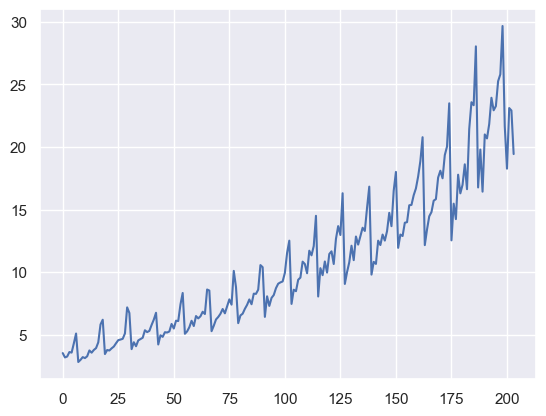

In [11]:
plt.plot(X)

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


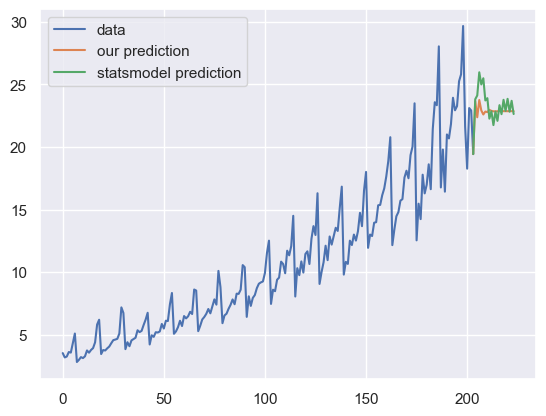

In [16]:
# our_model = ARIMACustom(X)
our_model = ARIMACustom(X, order=(4,1,3))
our_model.fit()
statsmodel_model = ARIMA(X, order=(our_model.p, our_model.d, our_model.q))
statsmodel_model = statsmodel_model.fit()
steps = 20

our_forecast = our_model.forecast(steps)
statsmodel_forecast = statsmodel_model.get_forecast(steps).predicted_mean
plt.plot(X, label="data")
plt.plot(range(len(X)-1,len(X)+steps), np.insert(our_forecast, 0, X[-1]), label="our prediction")
plt.plot(range(len(X)-1,len(X)+steps), np.insert(statsmodel_forecast, 0, X[-1]), label="statsmodel prediction")
plt.legend()

In [ ]:
model = ARIMA(X, order=(8,2,3))
model_fit = model.fit()
steps = 20

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
model_fit.params

array([-1.1521472 , -1.43355952, -0.95716187, -0.76519701, -0.63733586,
       -0.54325022, -0.46911353, -0.33629007, -0.3040949 ,  0.2439785 ,
       -0.93046319,  3.17037727])

In [ ]:
Y = np.diff(X, 1)

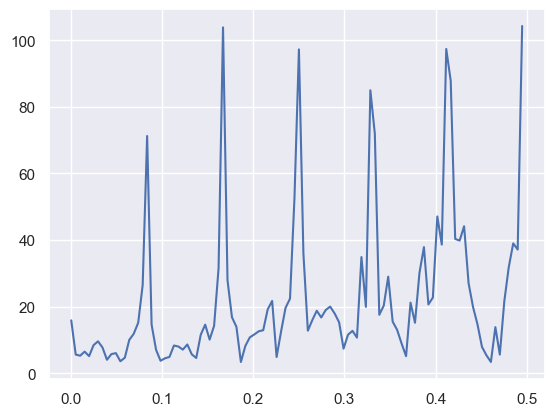

In [ ]:
import numpy as np
from scipy.fftpack import fft

n = len(X)
freqs = np.fft.fftfreq(n)
fft_values = np.abs(fft(np.diff(X,1)))

plt.plot(freqs[:n//2], fft_values[:n//2])  # Plot only positive frequencies
plt.show()

In [ ]:
fft_values[:n//2]

array([ 15.905149  ,   5.63352294,   5.28814947,   6.50914796,
         5.164294  ,   8.45616801,   9.60479997,   7.75813759,
         4.06930965,   5.77636183,   6.0661944 ,   3.62343095,
         4.68067989,  10.04528239,  11.87429769,  15.19894268,
        26.49989657,  71.25420541,  14.59926585,   7.06192397,
         3.7697075 ,   4.50981684,   4.91290629,   8.34839316,
         8.04416696,   7.11769621,   8.66190419,   5.69061044,
         4.59900996,  11.55236055,  14.61538701,  10.12676733,
        14.26217991,  31.55881177, 103.86410074,  27.97104687,
        16.83129203,  13.96464305,   3.39736536,   8.23030489,
        10.79984159,  11.6632275 ,  12.6206298 ,  12.93819423,
        19.16798263,  21.73478534,   4.89566133,  12.54486541,
        19.64802467,  22.40933379,  52.58783383,  97.25892386,
        36.064247  ,  12.79966995,  15.98800218,  18.78386544,
        16.76410162,  19.00834334,  20.03752282,  17.97611552,
        15.32121497,   7.40753943,  11.61116251,  12.74

In [ ]:
Y

array([ -0.3457    ,   0.07133   ,   0.358782  ,  -0.045134  ,
         0.740502  ,   0.781964  ,  -2.273815  ,   0.171291  ,
         0.218969  ,  -0.077202  ,   0.142945  ,   0.46732782,
        -0.17907473,   0.21842564,   0.14728869,   0.4620405 ,
         1.42401825,   0.38151852,  -2.7412107 ,   0.32144987,
        -0.03800396,   0.17109602,   0.14428822,   0.26587838,
         0.24661903,   0.04647748,   0.05918926,   0.42599016,
         2.08612075,  -0.44848912,  -2.8901955 ,   0.55279799,
        -0.31873484,   0.46530417,   0.10497018,   0.10699145,
         0.59799814,  -0.14614983,   0.09719646,   0.47209086,
         0.43085132,   0.54489034,  -2.53341647,   0.73328211,
        -0.12630456,   0.37170929,  -0.02396708,   0.08595446,
         0.59853572,  -0.36454828,   0.62456422,  -0.02682039,
         1.32812508,   0.9128542 ,  -3.25965627,   0.19276082,
         0.33456961,   0.51316972,  -0.42113516,   0.79768849,
        -0.18628   ,   0.16690641,   0.36115365,  -0.17

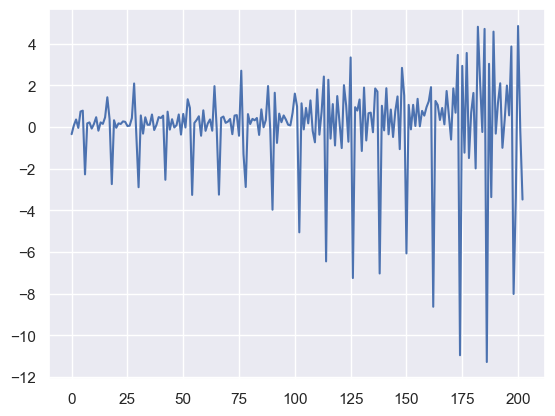

In [ ]:
plt.plot(Y)

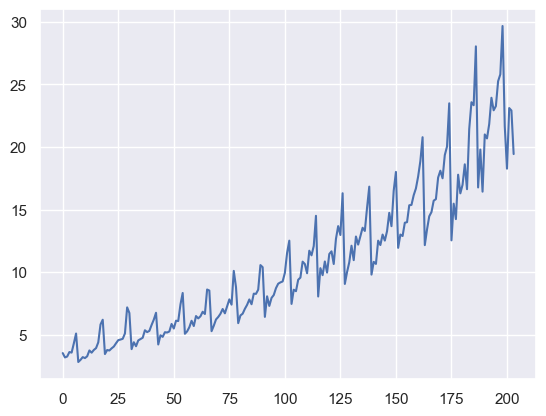

In [ ]:
plt.plot(X)

In [ ]:
date_filter = sample_dataset['date'].loc[sample_dataset['date'].str.endswith('01-01')]
date_filter

6      1992-01-01
18     1993-01-01
30     1994-01-01
42     1995-01-01
54     1996-01-01
66     1997-01-01
78     1998-01-01
90     1999-01-01
102    2000-01-01
114    2001-01-01
126    2002-01-01
138    2003-01-01
150    2004-01-01
162    2005-01-01
174    2006-01-01
186    2007-01-01
198    2008-01-01
Name: date, dtype: object

In [ ]:
result = adfuller(sample_dataset.value.dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: 3.145185689306738
p-value: 1.0


In [ ]:
def plot_acf(values, title):
    plt.rcParams.update({'figure.figsize':(20, 5), 'figure.dpi':120})

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    # Original Series ACF
    axes.plot(values)
    axes.set_title(title)

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values, ax=axes[0])
    tsaplots.plot_pacf(values, ax=axes[1])
    
    # 1st Differencing ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    axes.plot(values.diff())
    axes.set_title(f'{title} - 1st Order Differencing')

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values.diff().dropna(), ax=axes[0])
    tsaplots.plot_pacf(values.diff().dropna(), ax=axes[1])

    
    # 2nd Differencing ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    axes.plot(values.diff().diff())
    axes.set_title(f'{title} - 2nd Order Differencing')
    
    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values.diff().diff().dropna(), ax=axes[0])
    tsaplots.plot_pacf(values.diff().diff().dropna(), ax=axes[1])
    
    plt.show()

# Arima demonstration

Demonstrate your Arima implementation.

Add plots and figures.

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the statsmodels implementation. Hint: you can look at the documentation.


In order to demonstrate our result, we chose to use the following comparisons:

1. Comparison between the methods:
   - We made a comparison between the SKLearn Model and the Custom Model, while comparing the true labels / predicted labels of each one of the models using a confusion matrix, and also compare between their accuracies (In the bottom of the notebook, a comparison of all our experiments)
   - The accuracies are compared both for train set and both for test set
   - Since IRIS dataset is a well known dataset exact for these models, we've found a very high accuracy for both models
2. Comparison between the features:
   - The IRIS dataset has 4 features, and we compared the accuracy between all the possible feature pairs
   - Also, we built a boundry graph for each one of the pairs (A boundry graph can be built just for 2 features)
   - We found that the best combination are when one feature is Sepal and the other is Petal


In [ ]:
def run_arima(dataset, param, date_label):
    print("Training based on:")
    for k, v in param.items():
        print(f"{k} -> {v}")
        
    model = ARIMA(dataset.value, order=param["order"])
    model_fit = model.fit()
    print(model_fit.summary())

    plt.rcParams.update({'figure.figsize':(20, 5), 'figure.dpi':120})
    residuals = pd.DataFrame(model_fit.resid)
    fig, ax = plt.subplots(1,2)
    residuals.plot(title="Residuals", ax=ax[0])
    residuals.plot(kind='kde', title='Density', ax=ax[1])
    plt.show()

    forecast = model_fit.predict()
    forecast_df = pd.DataFrame({'date':dataset['date'], 'value':forecast.values})
    print(type(forecast))
    plt.plot(list(dataset['date']), list(forecast), label = "forecast")
    plt.plot(list(dataset['date']), list(dataset['value']), label = "actual")
    plt.xticks(date_label, rotation=30)
    plt.legend()
    plt.title('Actual vs forecast')
    plt.show()

    return forecast_df

In [ ]:
def run_arima_train_test(dataset, param, date_label):
    print("Train / Test based on:")

    split = int(len(dataset)*param["train_rate"])
    train_dataset = dataset[:split]
    test_dataset = dataset[split:]
    
    for k, v in param.items():
        print(f"{k} -> {v}")
    model = ARIMA(train_dataset.value, order=param["order"])
    model_fit = model.fit()
    print(model_fit.summary())

    plt.rcParams.update({'figure.figsize':(20, 5), 'figure.dpi':120})
    residuals = pd.DataFrame(model_fit.resid)
    fig, ax = plt.subplots(1,2)
    residuals.plot(title="Residuals", ax=ax[0])
    residuals.plot(kind='kde', title='Density', ax=ax[1])
    plt.show()

    forecast = model_fit.get_forecast(len(dataset) - split, alpha=0.05)  # 95% conf
    forecast_df = pd.DataFrame({'date':test_dataset['date'], 'value': forecast.predicted_mean})
    #print(type(forecast))
    plt.plot(list(train_dataset['date']), list(train_dataset['value']), label = "training")
    plt.plot(list(test_dataset['date']), list(test_dataset['value']), label = "actual")
    plt.plot(list(forecast_df['date']), list(forecast_df['value']), label = "forecast")
    plt.fill_between(list(forecast_df['date']), 
                 forecast.conf_int().iloc[:, 0], 
                 forecast.conf_int().iloc[:, 1], 
                 color='k', alpha=.15)
    plt.xticks(date_label, rotation=30)
    plt.legend()
    plt.title('Training / Actual vs forecast')
    plt.show()

    return forecast_df

ACF / PACF of original data


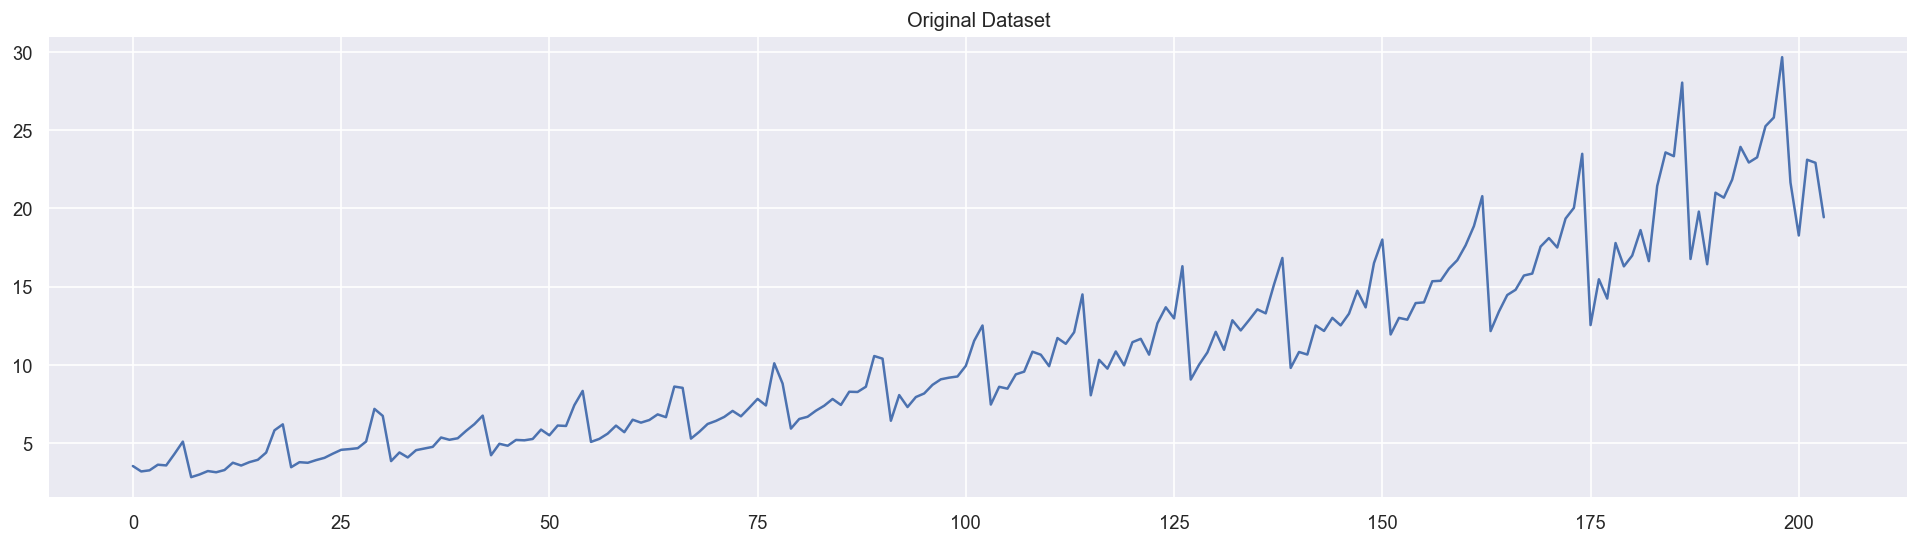

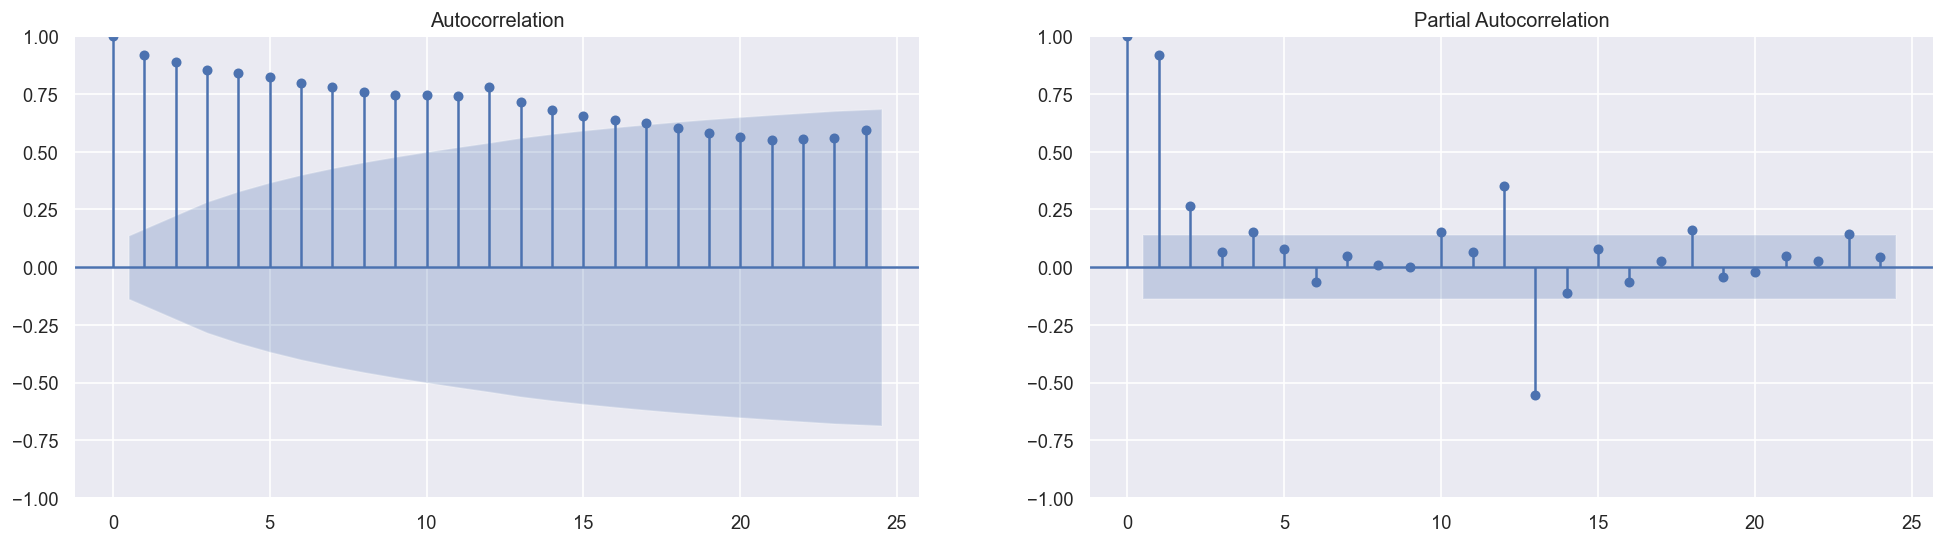

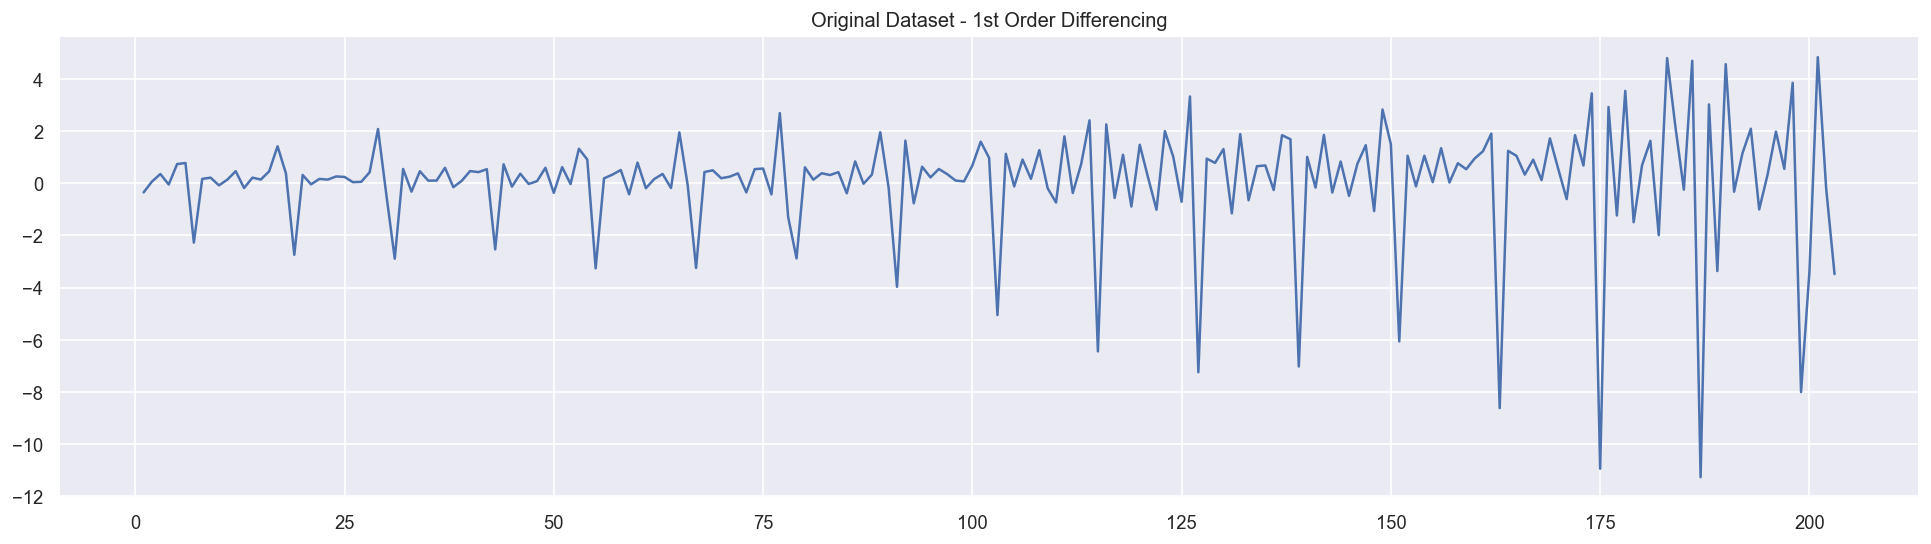

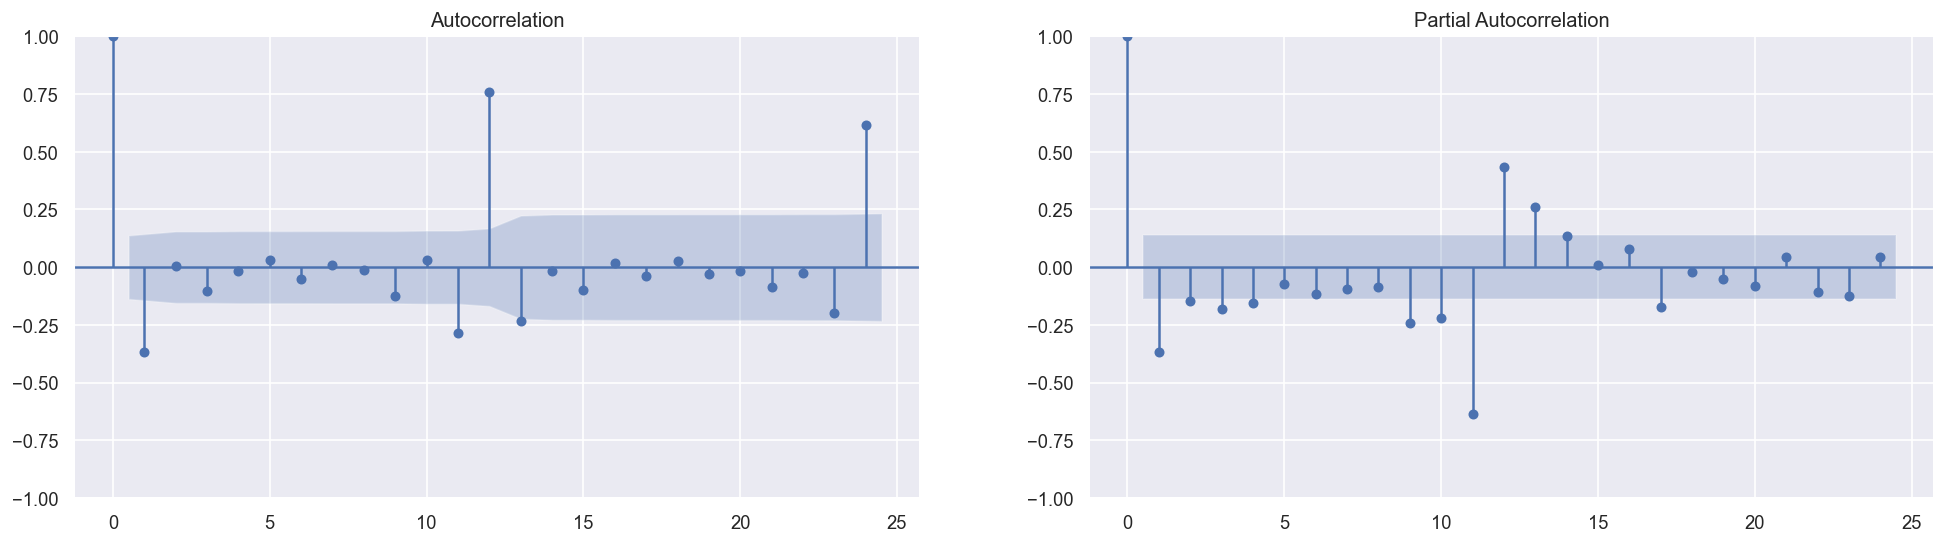

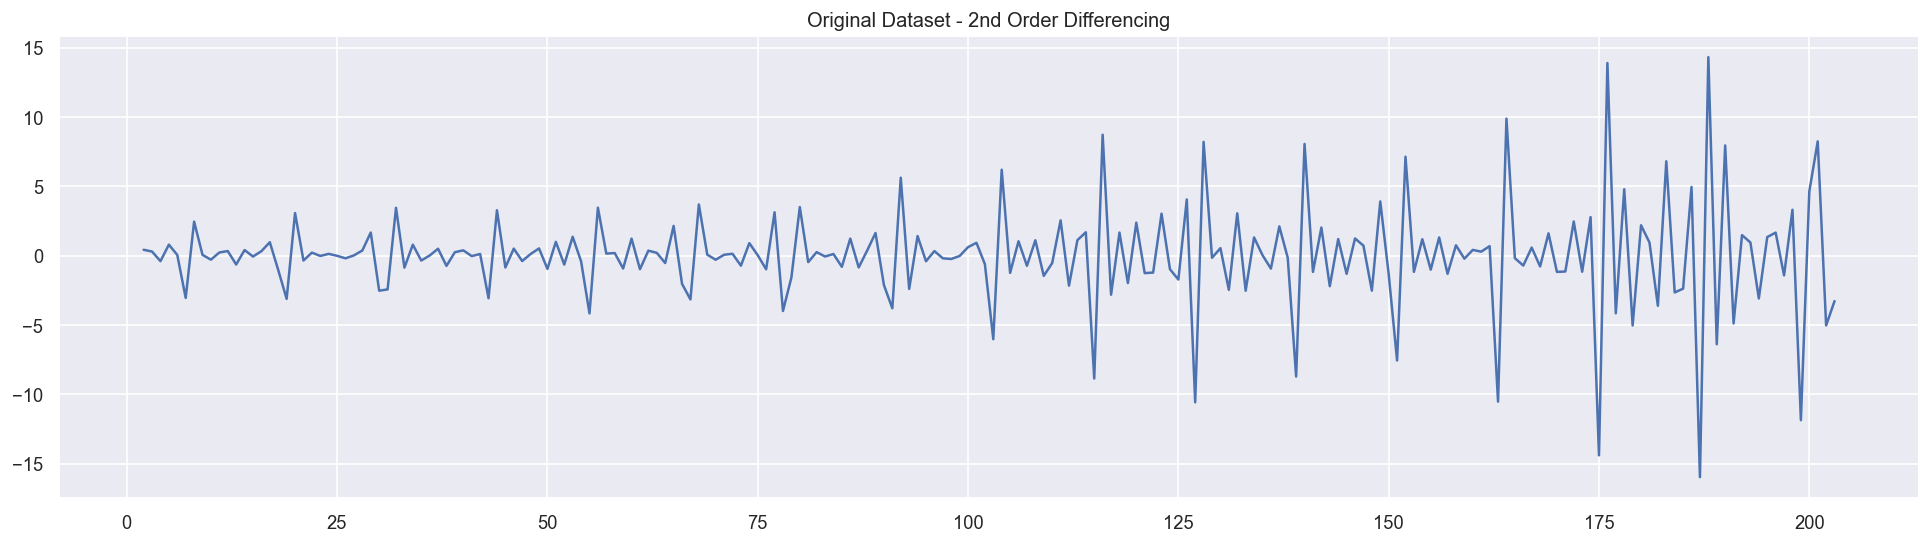

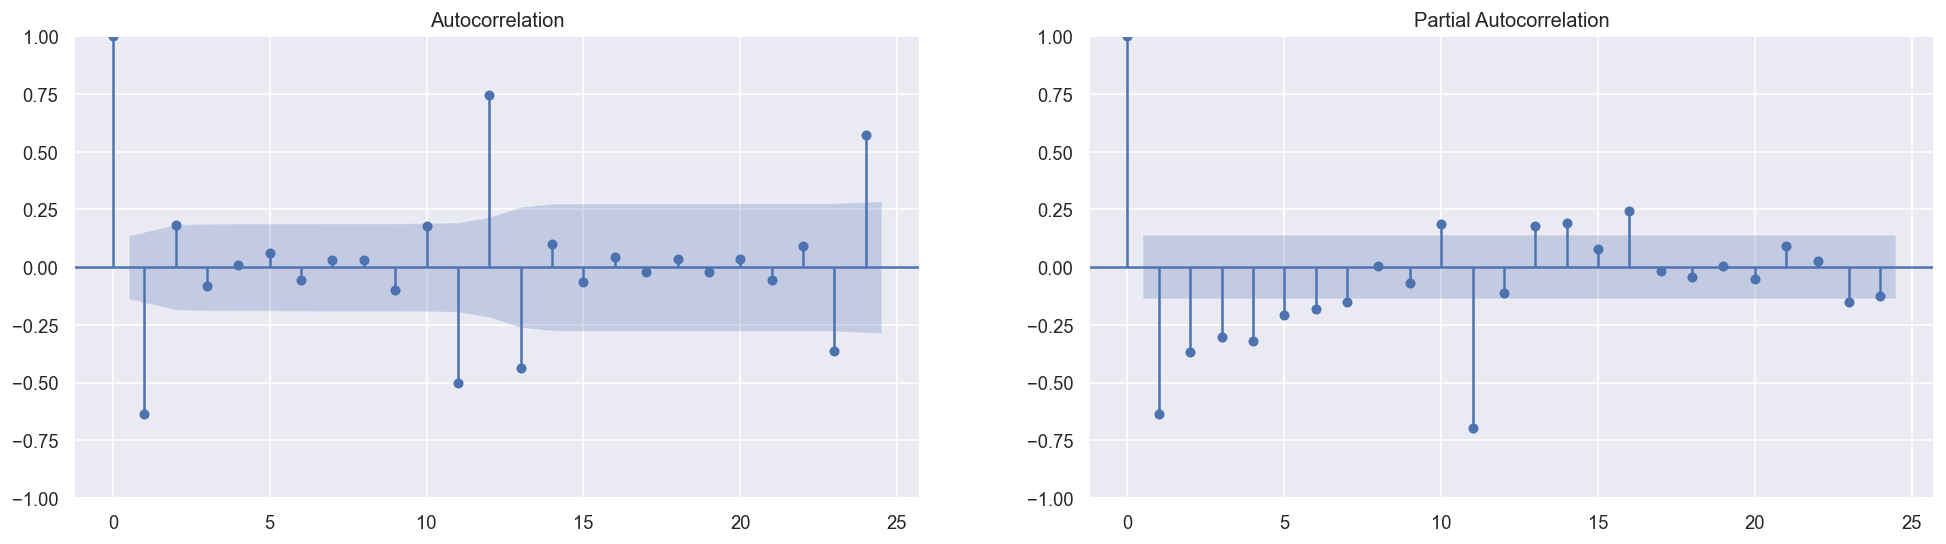

6      1992-01-01
18     1993-01-01
30     1994-01-01
42     1995-01-01
54     1996-01-01
66     1997-01-01
78     1998-01-01
90     1999-01-01
102    2000-01-01
114    2001-01-01
126    2002-01-01
138    2003-01-01
150    2004-01-01
162    2005-01-01
174    2006-01-01
186    2007-01-01
198    2008-01-01
Name: date, dtype: object
Training based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  204
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -432.842
Date:                Wed, 12 Mar 2025   AIC                            875.683
Time:                        02:49:18   BIC                            892.225
Sample:                             0   HQIC                           882.376
                                - 204                                         
Covariance Type:                  opg                      

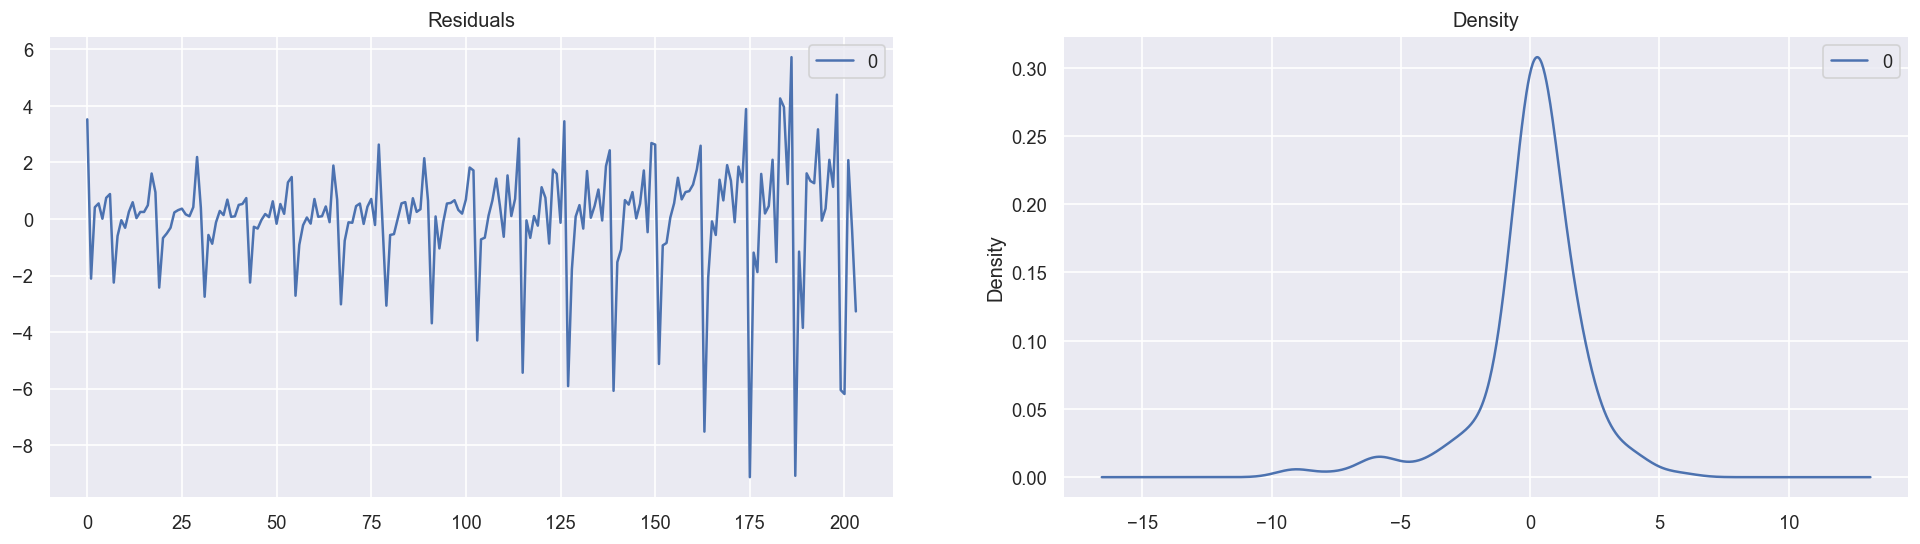

<class 'pandas.core.series.Series'>


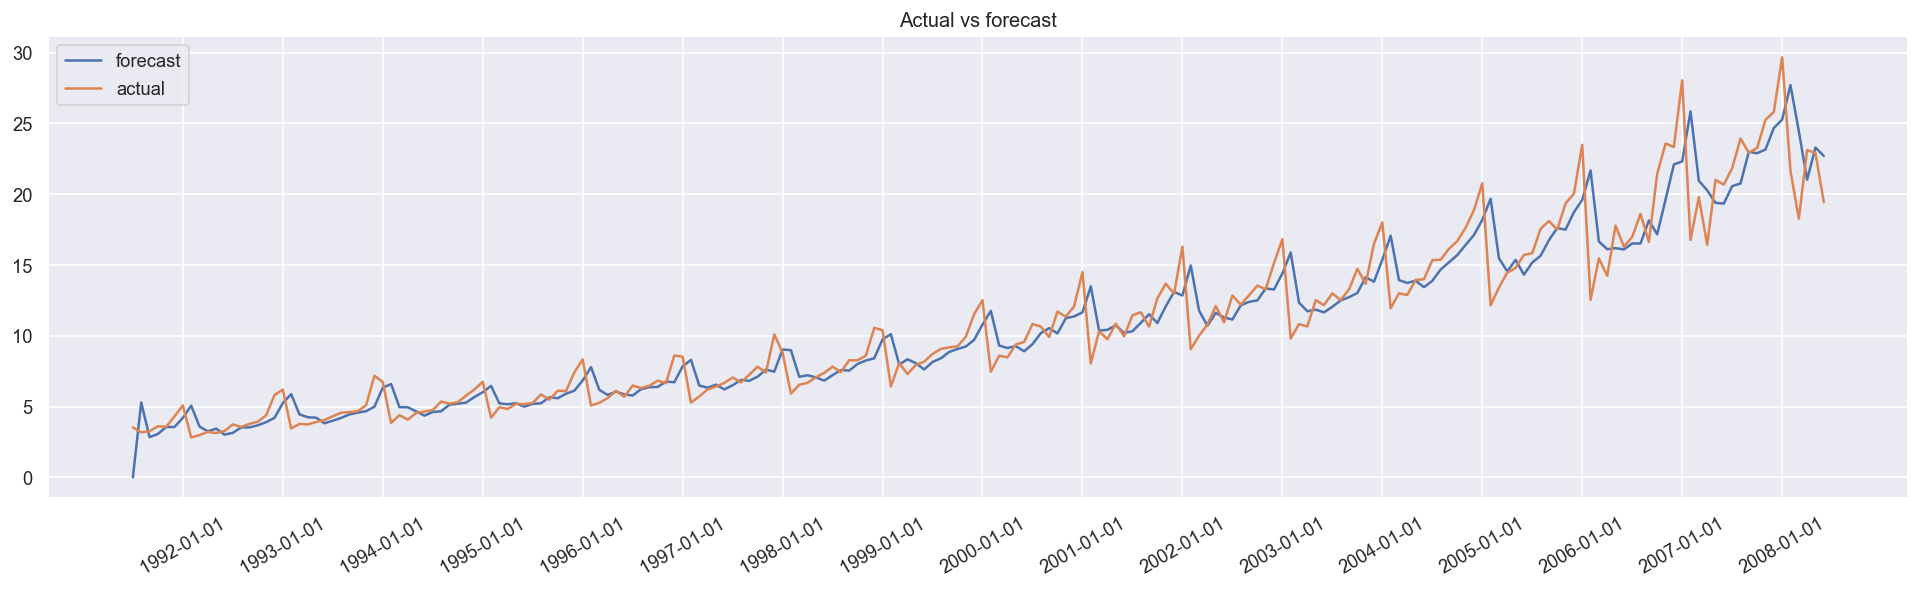

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -251.244
Date:                Wed, 12 Mar 2025   AIC                            512.488
Time:                        02:49:20   BIC                            527.196
Sample:                             0   HQIC                           518.465
                                - 142                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4415      0.124     -3.553      0.000      -0.685      -0.198
ar.L2         -0.2760      0.123     -2.251      0.024      -0.516     

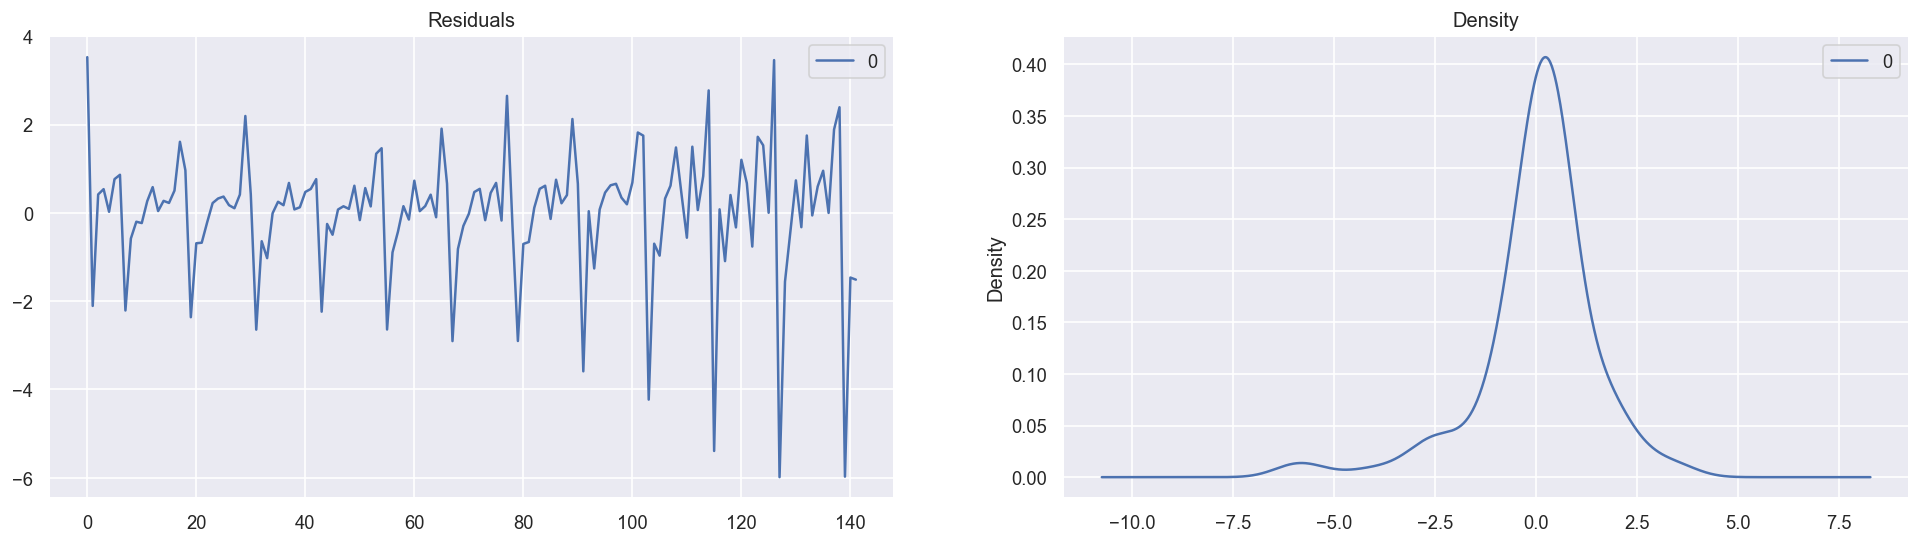

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


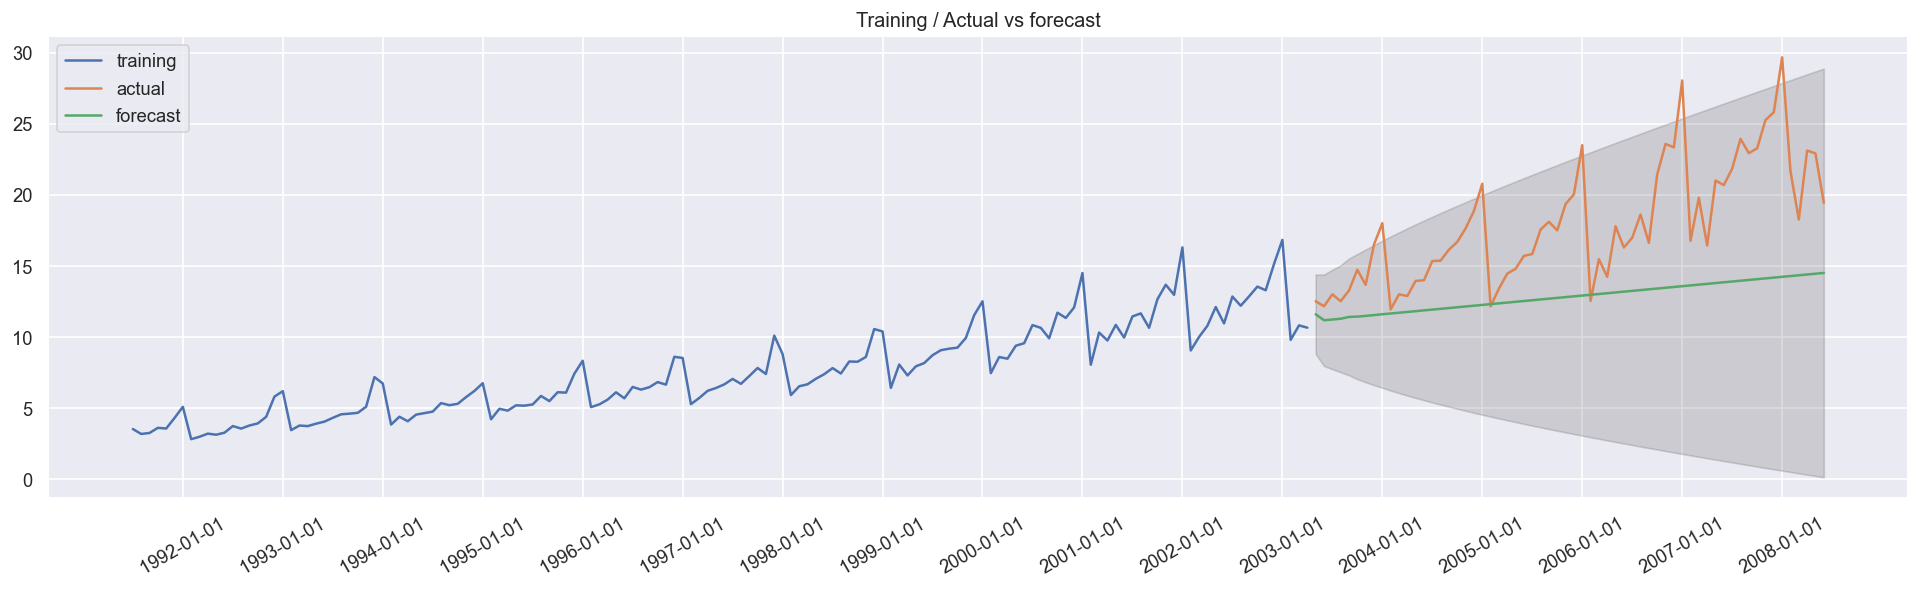

Training based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  204
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -424.570
Date:                Wed, 12 Mar 2025   AIC                            857.140
Time:                        02:49:21   BIC                            870.393
Sample:                             0   HQIC                           862.502
                                - 204                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4178      0.356      1.174      0.240      -0.280       1.115
ma.L1         -0.9546      0.377     -2.531      0.011      -1.694      -0.

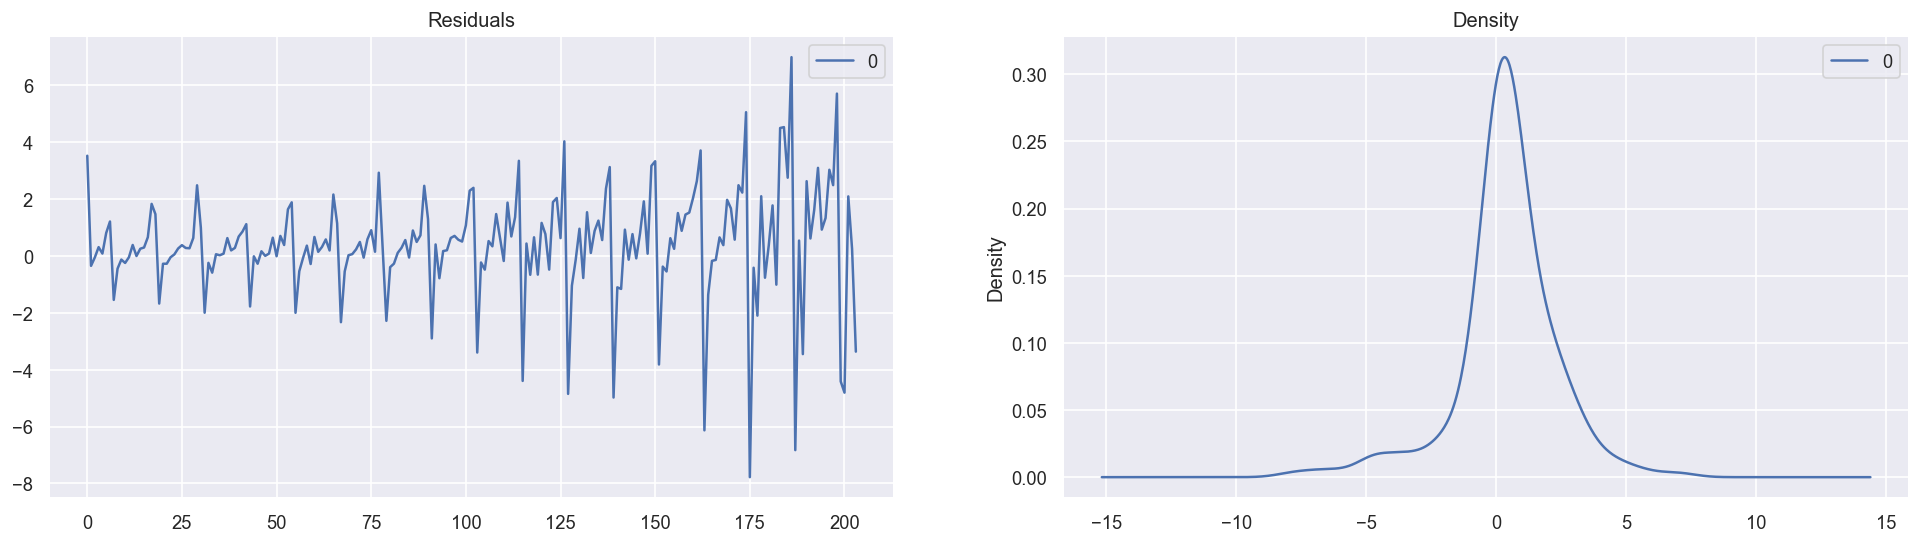

<class 'pandas.core.series.Series'>


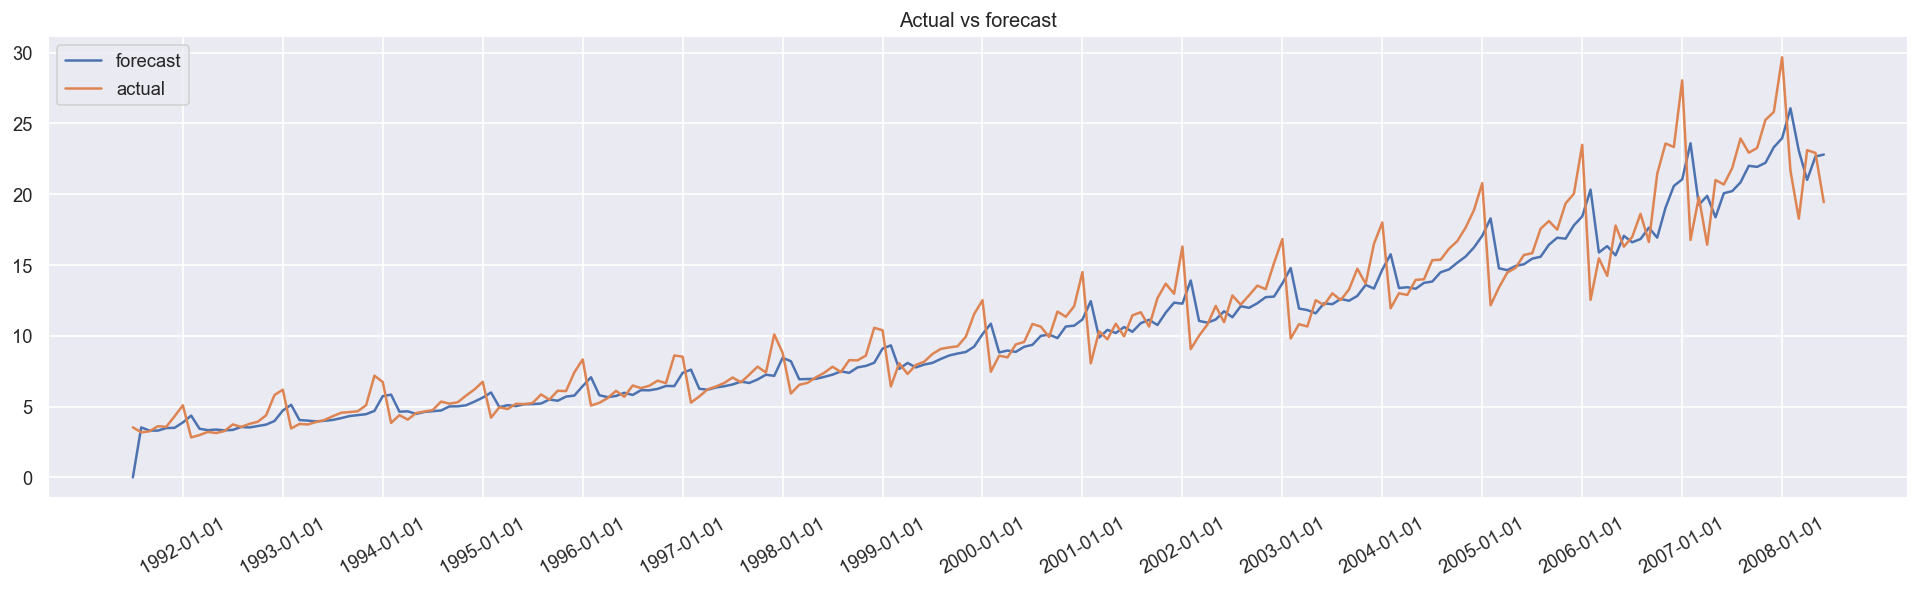

Train / Test based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -242.893
Date:                Wed, 12 Mar 2025   AIC                            493.786
Time:                        02:49:22   BIC                            505.581
Sample:                             0   HQIC                           498.579
                                - 142                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2453      0.591      0.415      0.678      -0.914       1.404
ma.L1         -0.8013      0.569     -1.408      0.159      -1.917     

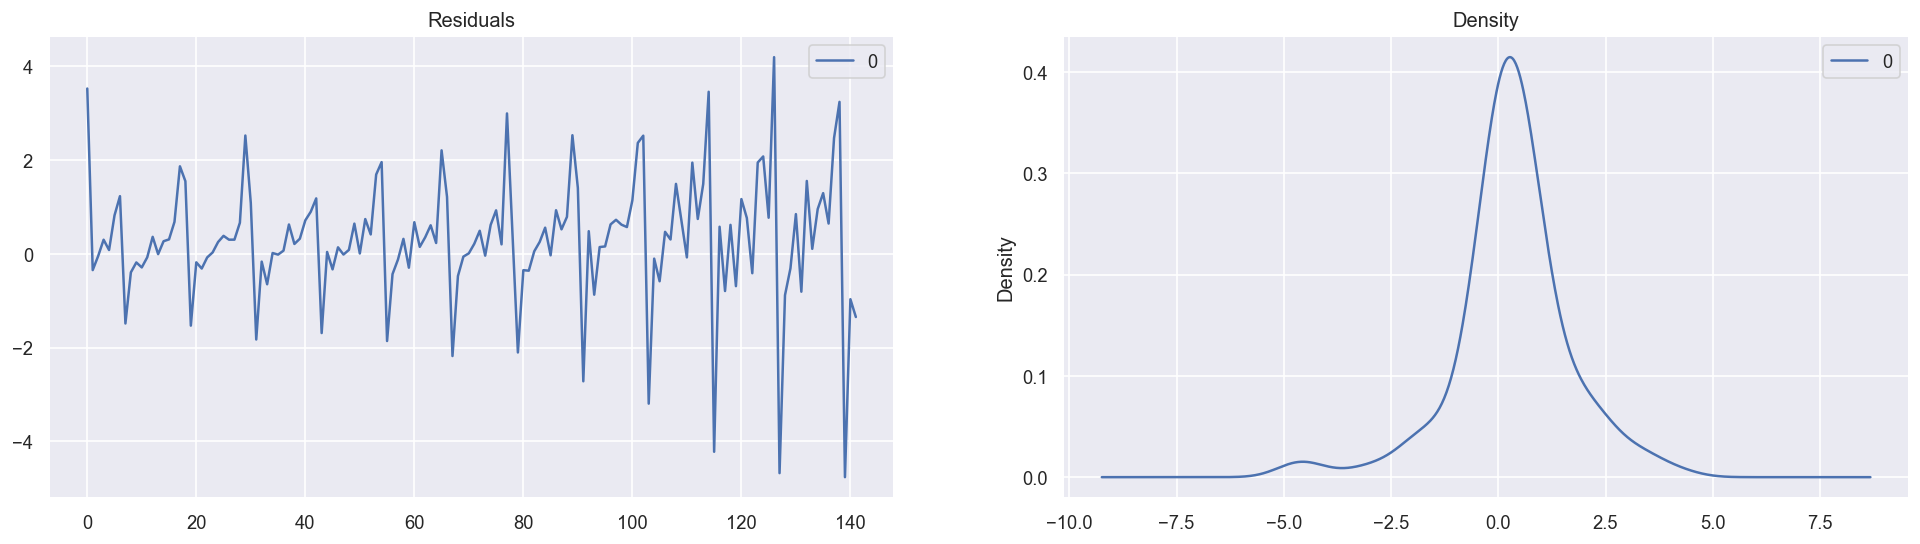

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


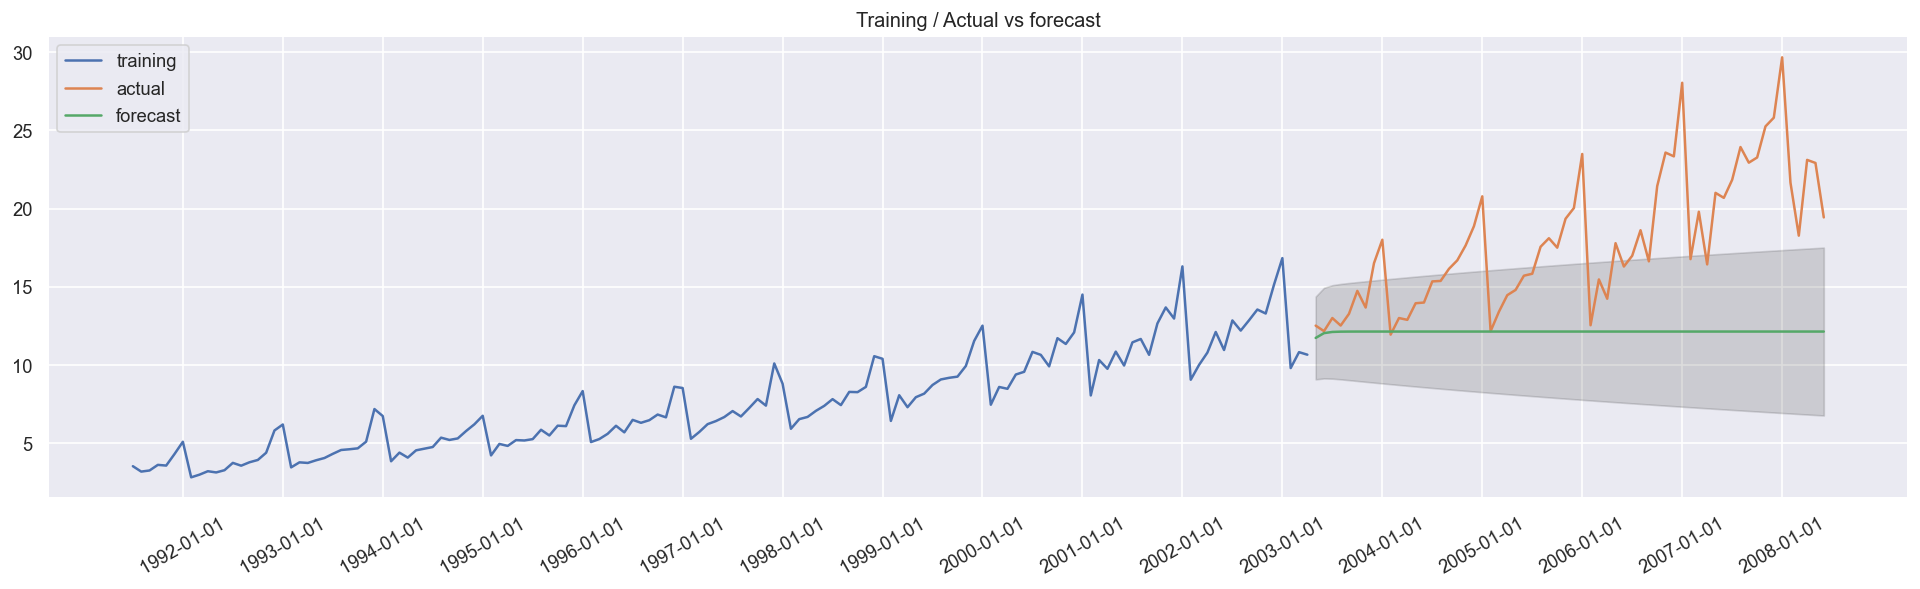

Training based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  204
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -424.762
Date:                Wed, 12 Mar 2025   AIC                            855.524
Time:                        02:49:23   BIC                            865.463
Sample:                             0   HQIC                           859.545
                                - 204                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3009      0.094      3.195      0.001       0.116       0.485
ma.L1         -0.8300      0.048    -17.204      0.000      -0.925      -0.

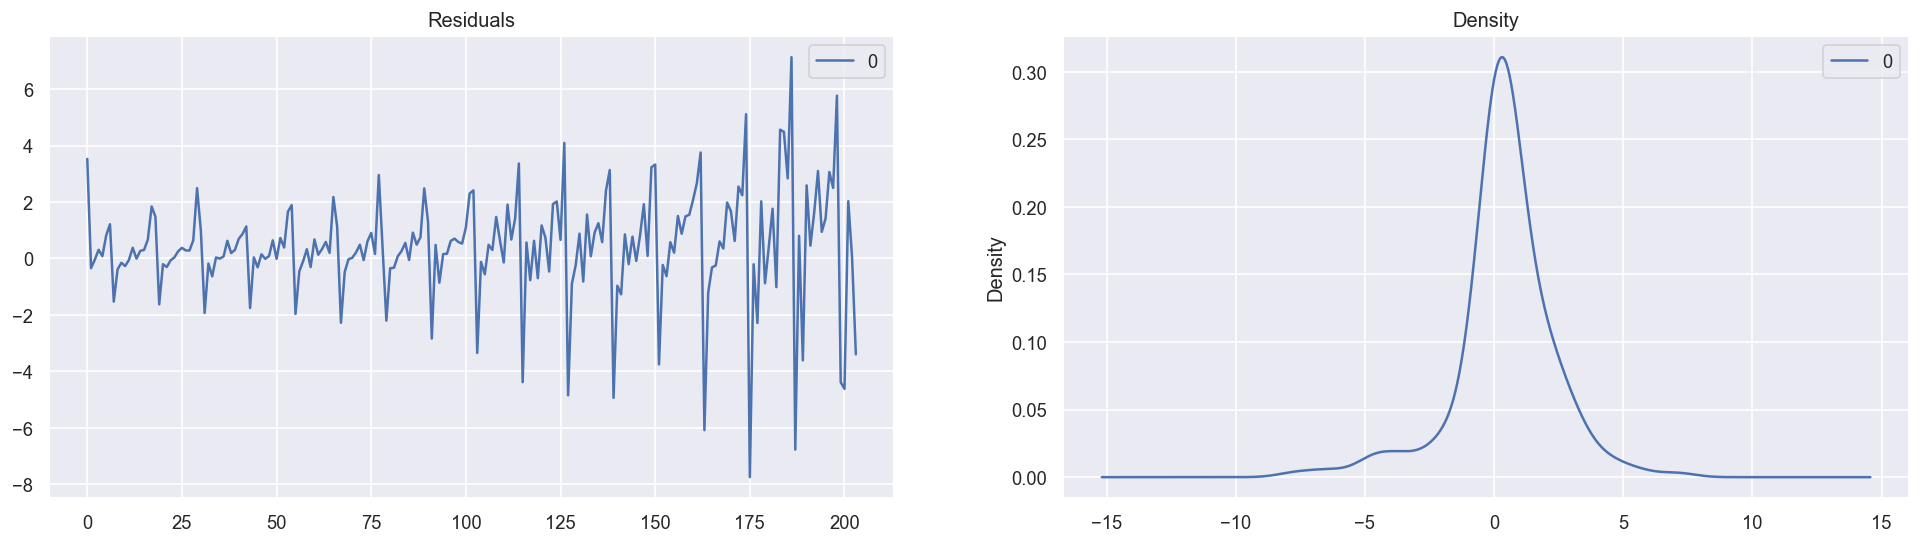

<class 'pandas.core.series.Series'>


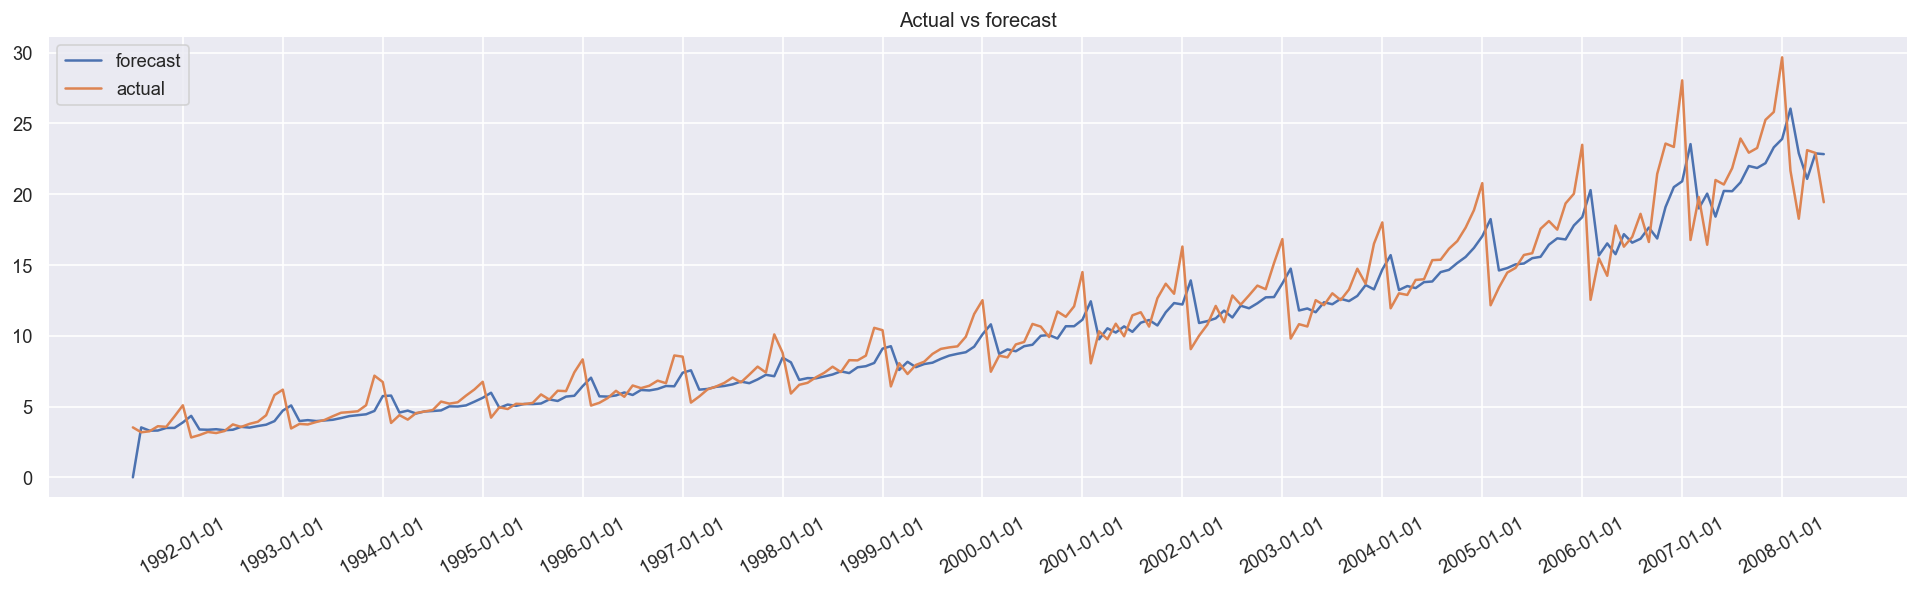

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -242.904
Date:                Wed, 12 Mar 2025   AIC                            491.808
Time:                        02:49:24   BIC                            500.654
Sample:                             0   HQIC                           495.402
                                - 142                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2844      0.185      1.539      0.124      -0.078       0.647
ma.L1         -0.8431      0.089     -9.435      0.000      -1.018     

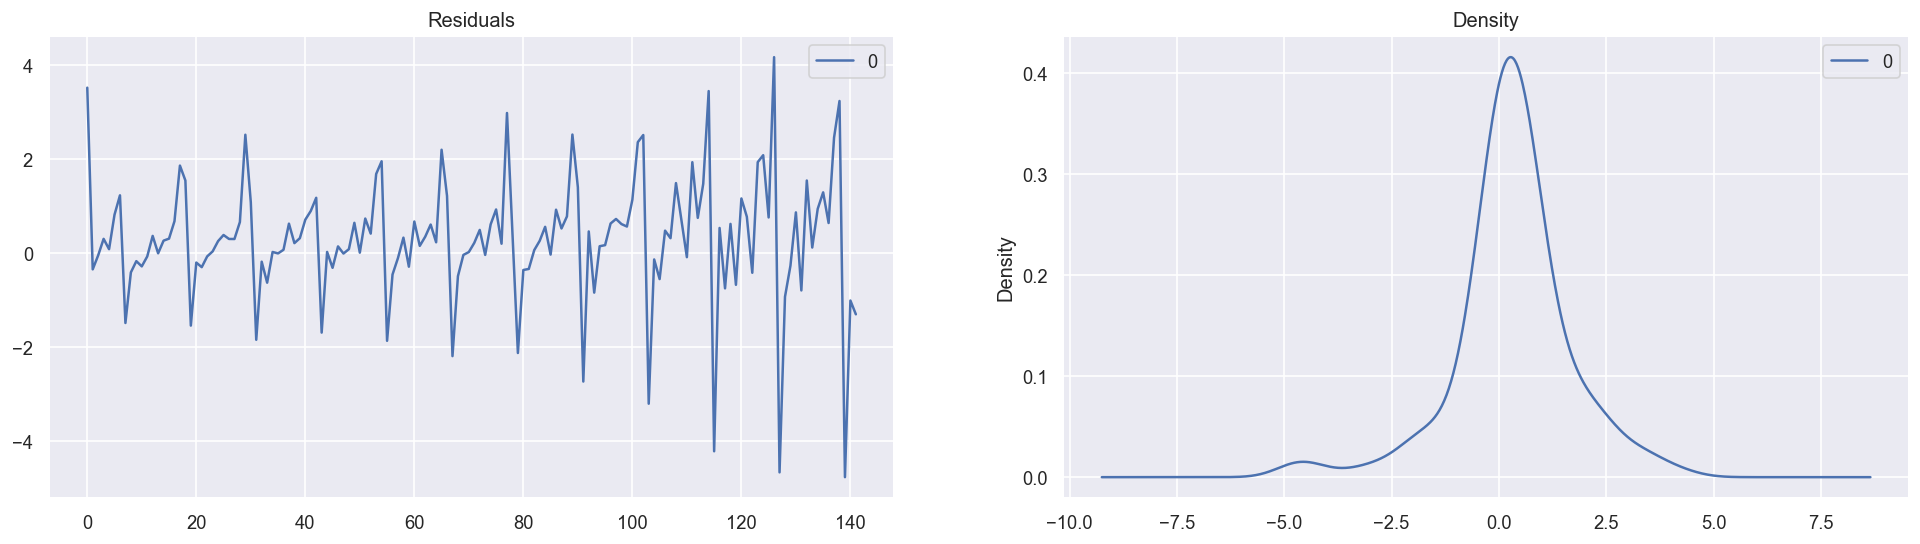

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


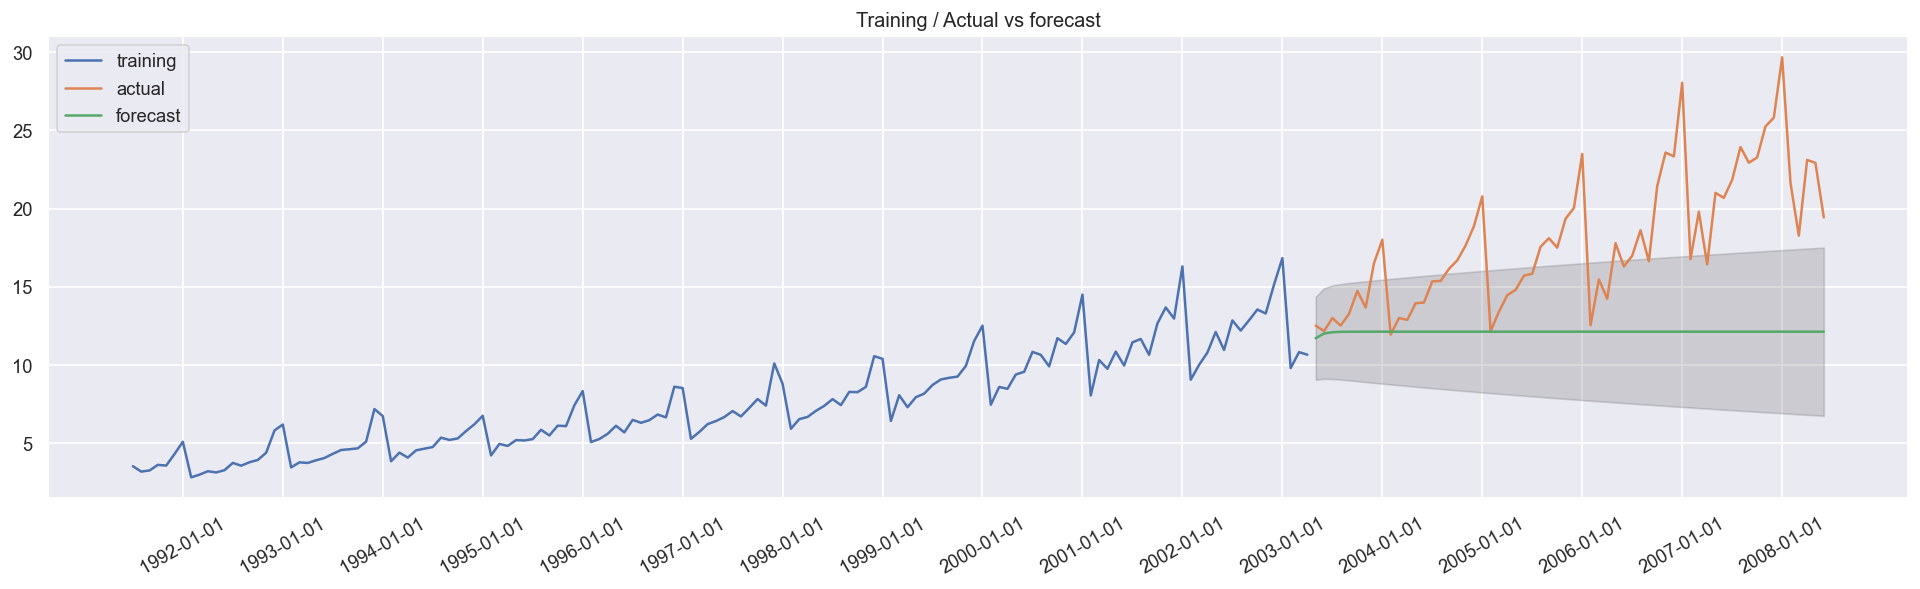

In [ ]:
hyperparams = [{
    "order": (3, 2, 1),
     "train_rate": 0.7
},{
    "order": (1, 1, 2),
     "train_rate": 0.7
},{
    "order": (1, 1, 1),
     "train_rate": 0.7
}]

print("ACF / PACF of original data")
plot_acf(sample_dataset.value, "Original Dataset")
print("==================================================================================================")
date_label = sample_dataset['date'].loc[sample_dataset['date'].str.endswith('01-01')]

print(date_label)
for idx, param in enumerate(hyperparams):
    predicted_dataset = run_arima(sample_dataset, param, date_label)
    print("==================================================================================================")
    predicted_dataset = run_arima_train_test(sample_dataset, param, date_label)
    print("==================================================================================================")

# AMZN Dataset


In [ ]:
path = './AMZN_data_1999_2022.csv'

amzn_dataset_original = pd.read_csv(path)

amzn_dataset_original.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1999-01-04,2.730729,2.966667,2.665625,2.957813,2.957813,785844000
1,1999-01-05,2.739063,3.243750,2.662500,3.112500,3.112500,1257464000
2,1999-01-06,3.409375,3.509375,3.350000,3.450000,3.450000,723532000
3,1999-01-07,3.428125,4.006250,3.325000,3.971875,3.971875,945492000
4,1999-01-08,4.606250,4.978125,3.800000,4.006250,4.006250,1333244000


In [ ]:
ticker = yf.Ticker('AMZN')

amzn_dataset_original = ticker.history(period="max").reset_index() 
amzn_dataset_original['Date'] = amzn_dataset_original['Date'].astype(str)
amzn_dataset_original['Date'] = amzn_dataset_original['Date'].str.split().str[0]

amzn_dataset_original.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,1443120000,0.0,0.0
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,294000000,0.0,0.0
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,122136000,0.0,0.0
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,109344000,0.0,0.0
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,377064000,0.0,0.0


In [ ]:
mean_list = np.mean( np.array([ amzn_dataset_original['Low'], amzn_dataset_original['High'] ]), axis=0 )
datasets = {
    #'open': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Open']}),
    #'close': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Close']}),
    #'high': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['High']}),
    #'low': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Low']}),
    'mean': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':mean_list}),
    'volume': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Volume']})
}

In [ ]:
def get_date_labels_amzn(dataset):
    date_filter = dataset.loc[dataset['date'].str.endswith('01-02') ^ dataset['date'].str.endswith('01-03') ^ dataset['date'].str.endswith('01-04')]
    date_filter['year'] = date_filter['date'].str.split('-').str[0]
    date_filter.loc[0] = dataset.iloc[0]
    date_filter.at[0, 'year'] = 'first'
    date_filter.loc[len(dataset)-1] = dataset.iloc[-1]
    date_filter.at[len(dataset)-1, 'year'] = 'last'
    date_filter = date_filter.drop_duplicates(subset=['year'], keep='first')
    date_filter = date_filter.loc[:, 'date']
    date_filter = date_filter.sort_index()
    
    return date_filter

C:\Users\Roey\AppData\Local\Temp\ipykernel_24516\2499829597.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter['year'] = date_filter['date'].str.split('-').str[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_24516\2499829597.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter.loc[0] = dataset.iloc[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_24516\2499829597.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

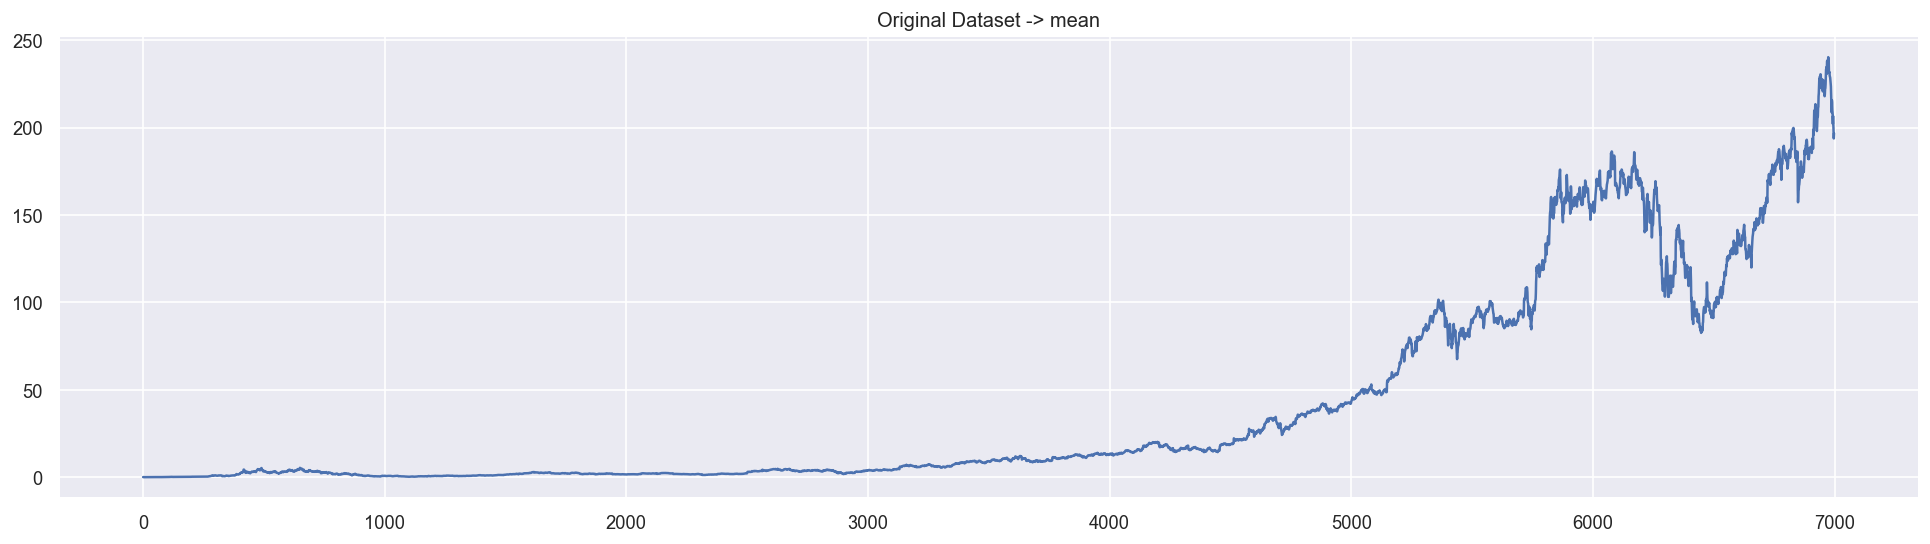

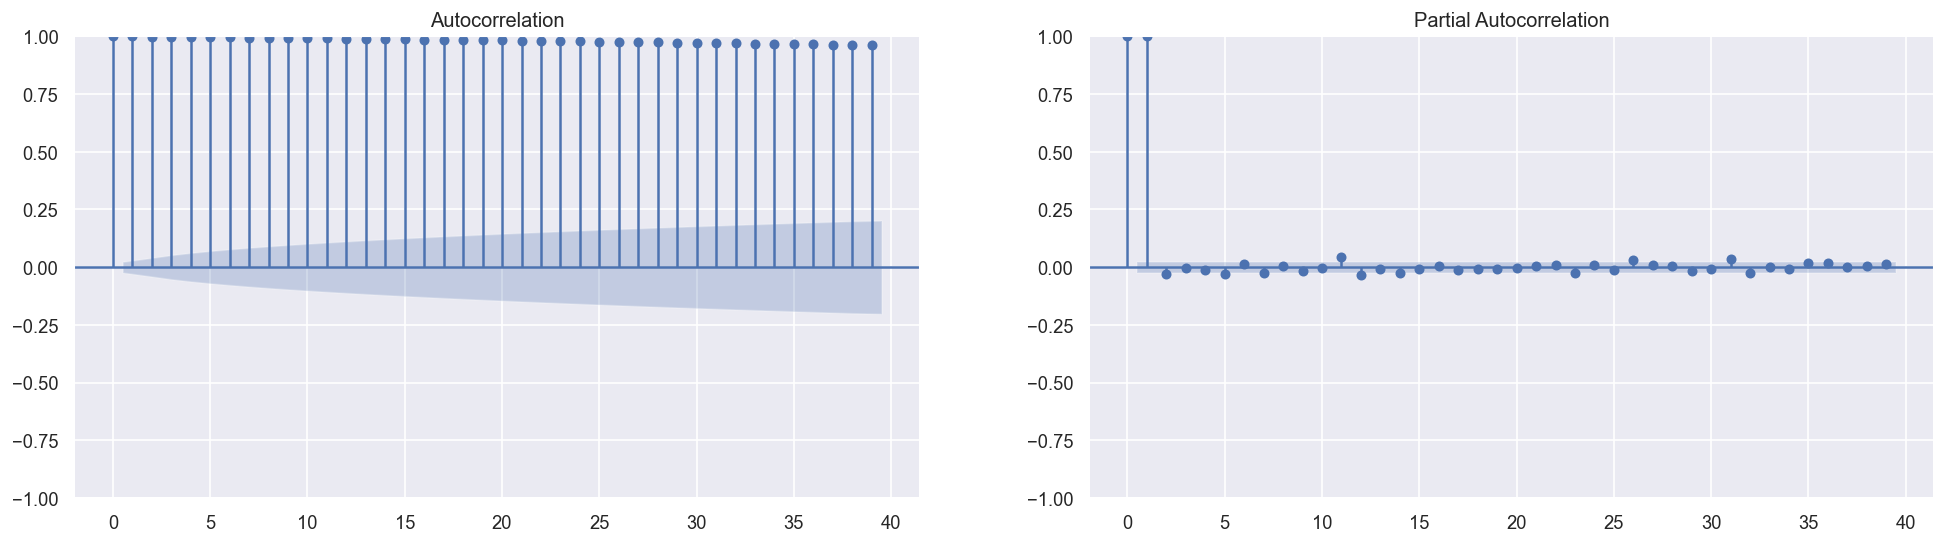

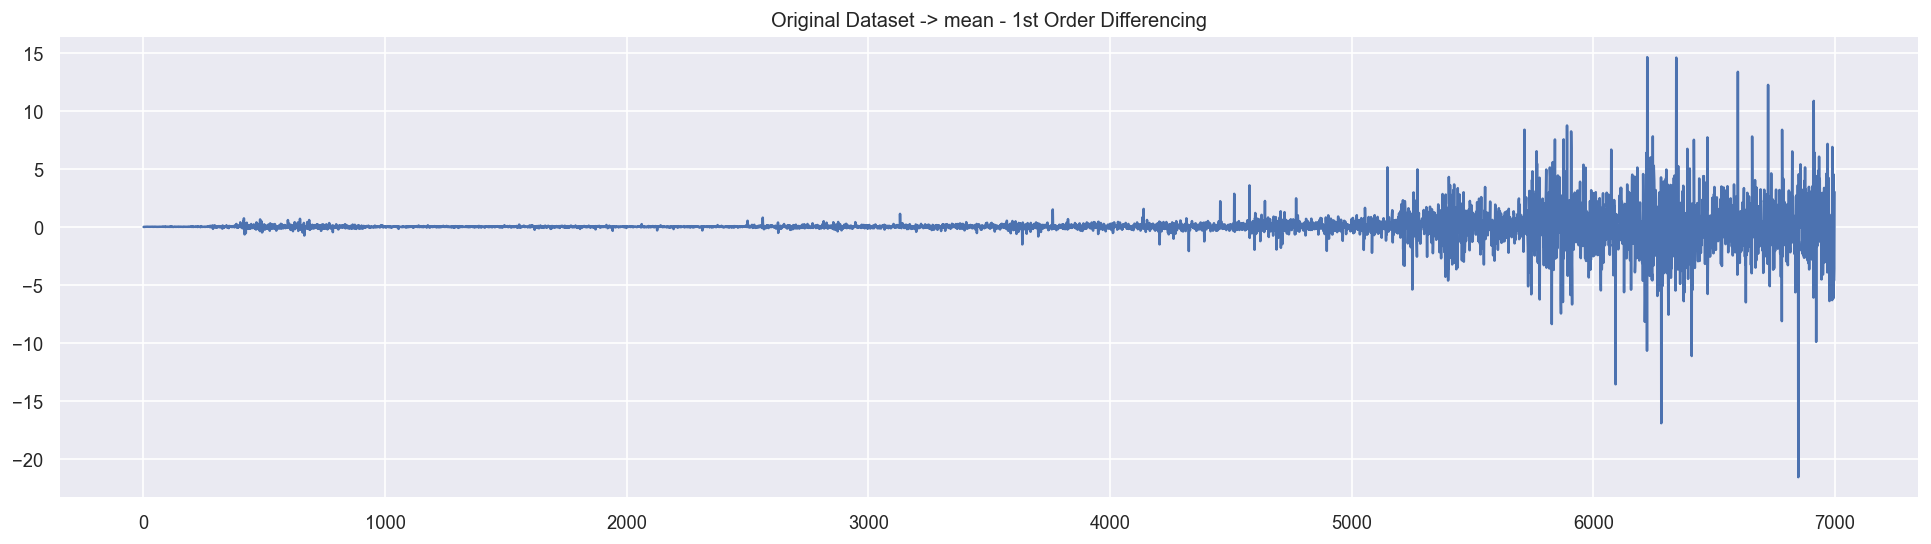

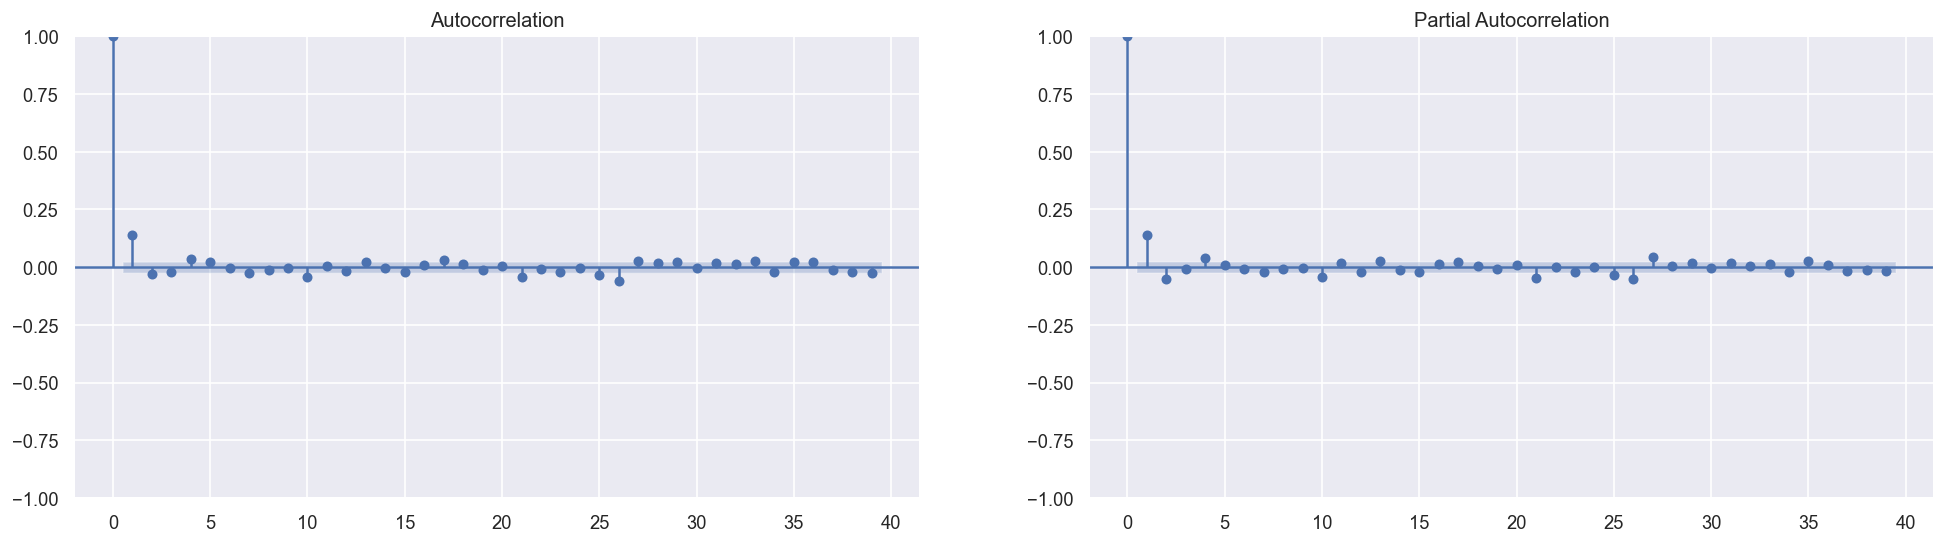

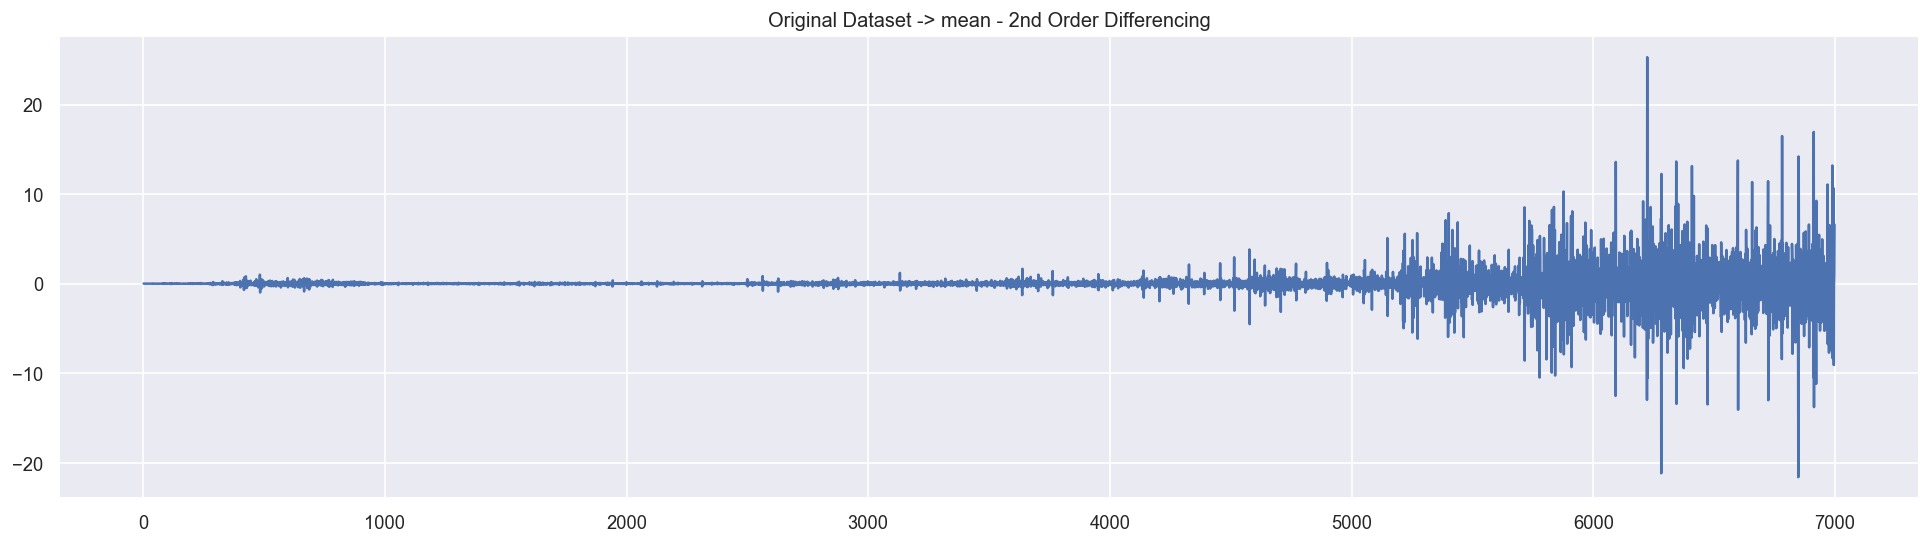

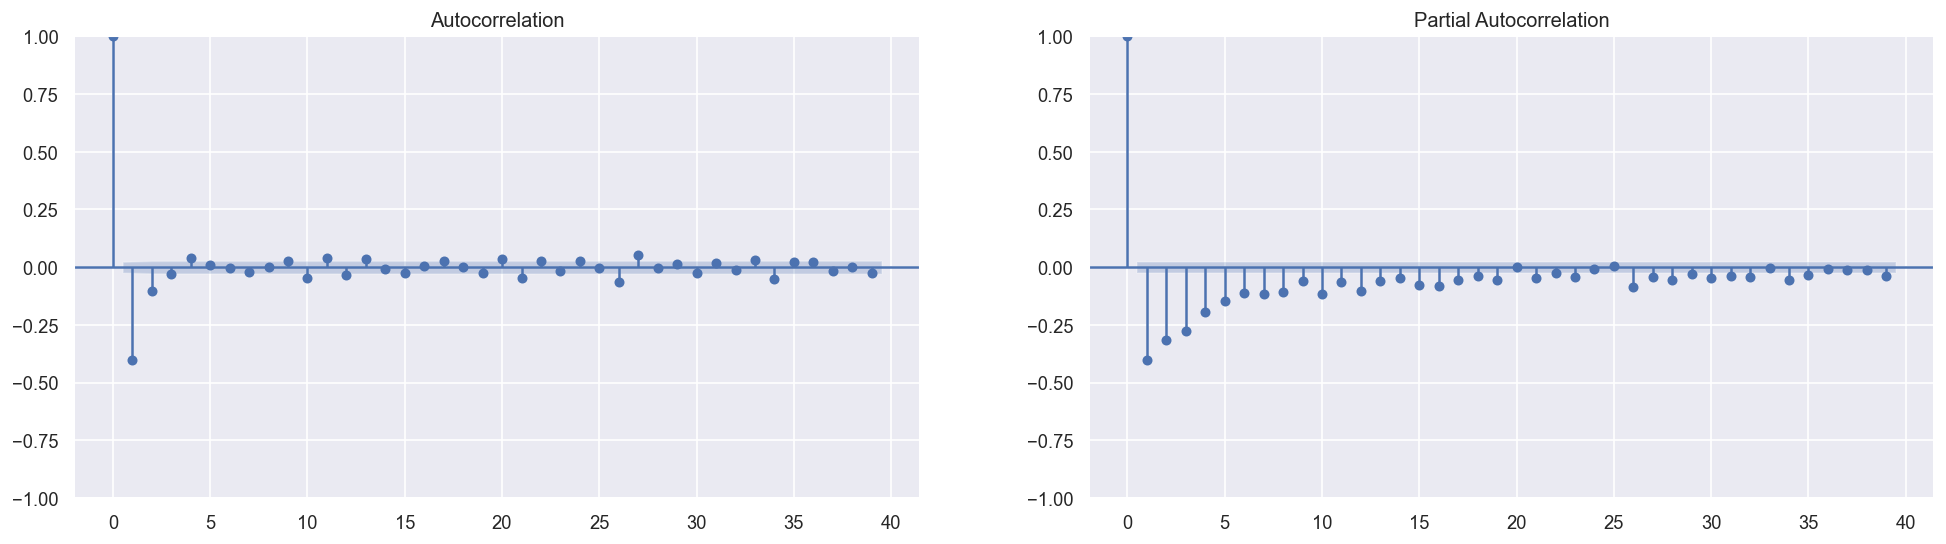

Train / Test based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4899
Model:                 ARIMA(1, 1, 2)   Log Likelihood                1020.574
Date:                Wed, 12 Mar 2025   AIC                          -2033.149
Time:                        02:49:30   BIC                          -2007.162
Sample:                             0   HQIC                         -2024.031
                               - 4899                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6414      0.210      3.058      0.002       0.230       1.052
ma.L1         -0.5018      0.209     -2.403      0.016      -0.911     

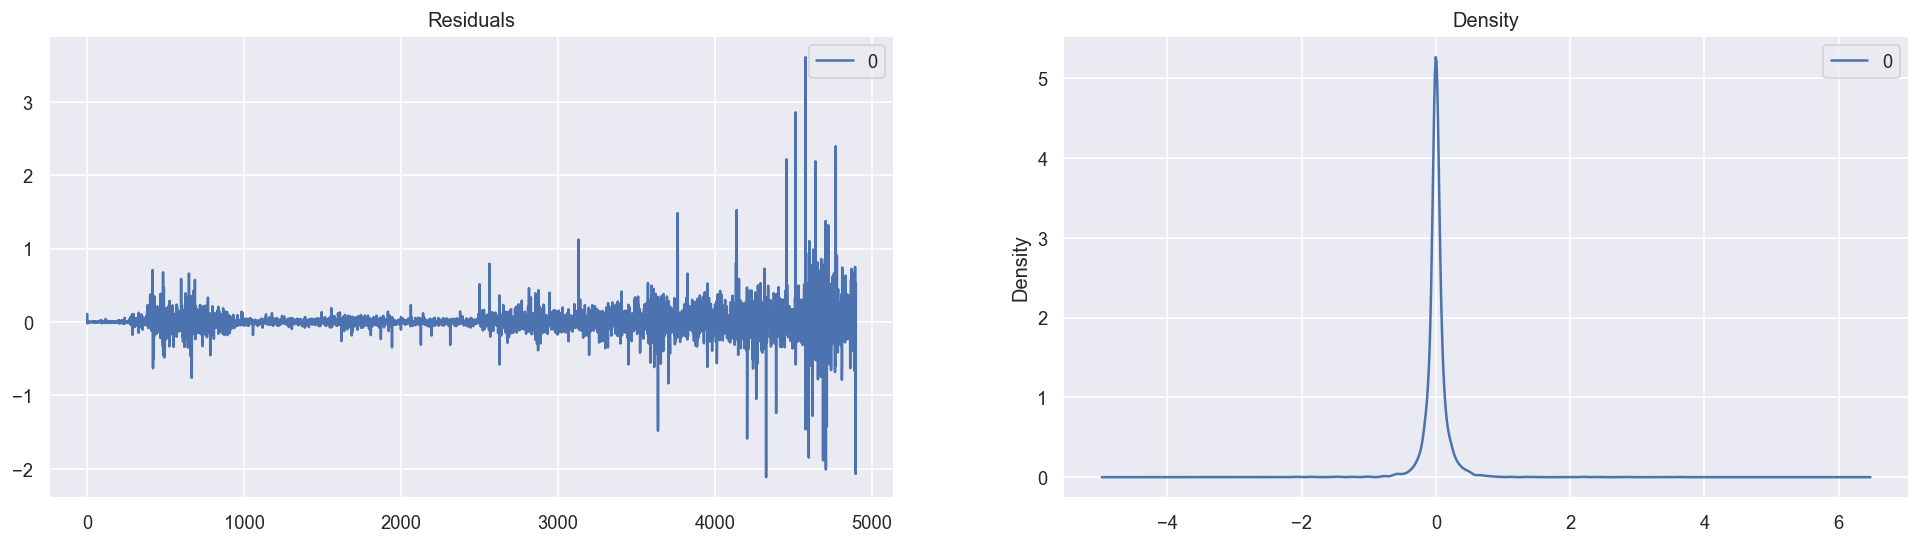

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


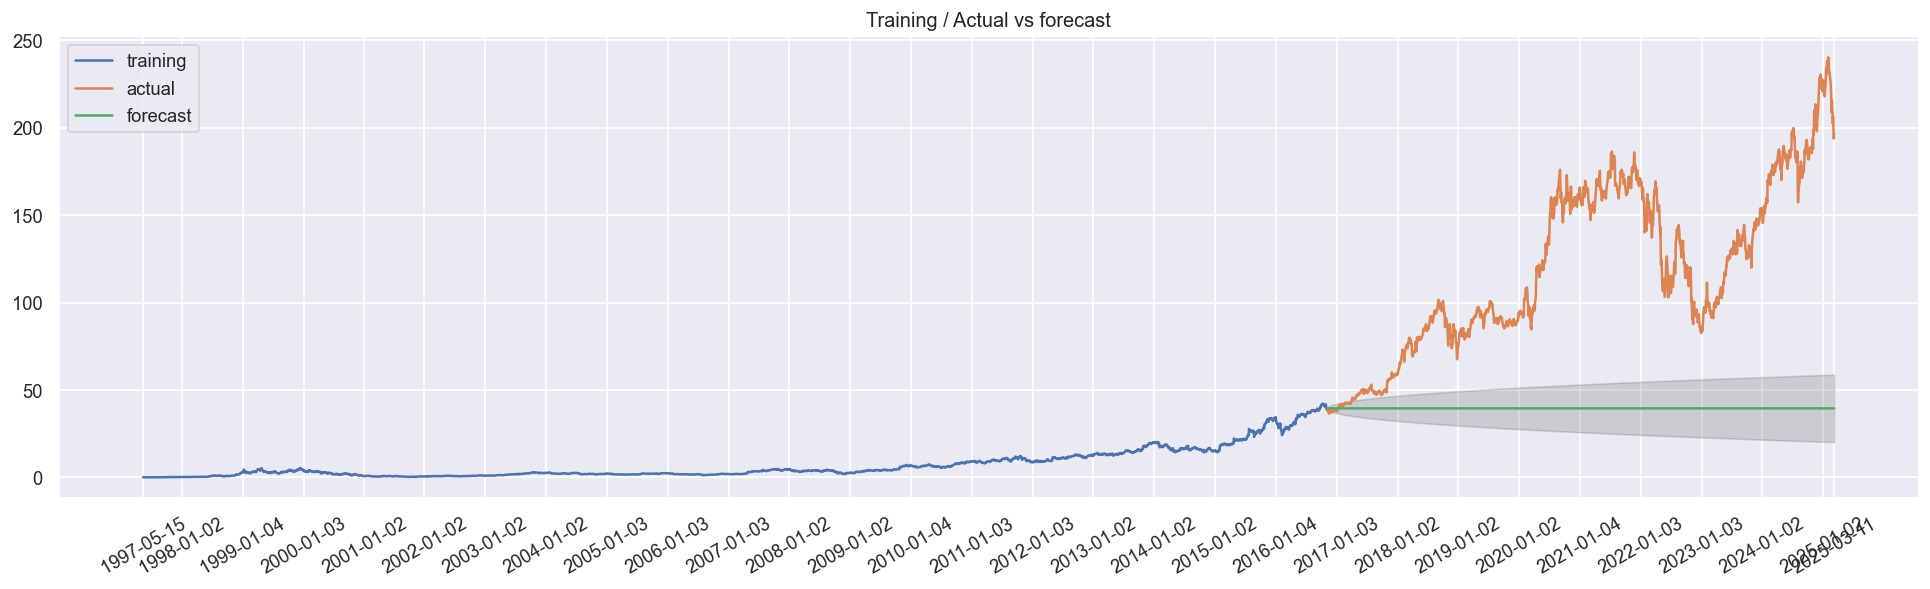

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4899
Model:                 ARIMA(1, 1, 1)   Log Likelihood                1019.561
Date:                Wed, 12 Mar 2025   AIC                          -2033.123
Time:                        02:49:33   BIC                          -2013.633
Sample:                             0   HQIC                         -2026.285
                               - 4899                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0011      0.055      0.020      0.984      -0.107       0.109
ma.L1          0.1416      0.055      2.587      0.010       0.034     

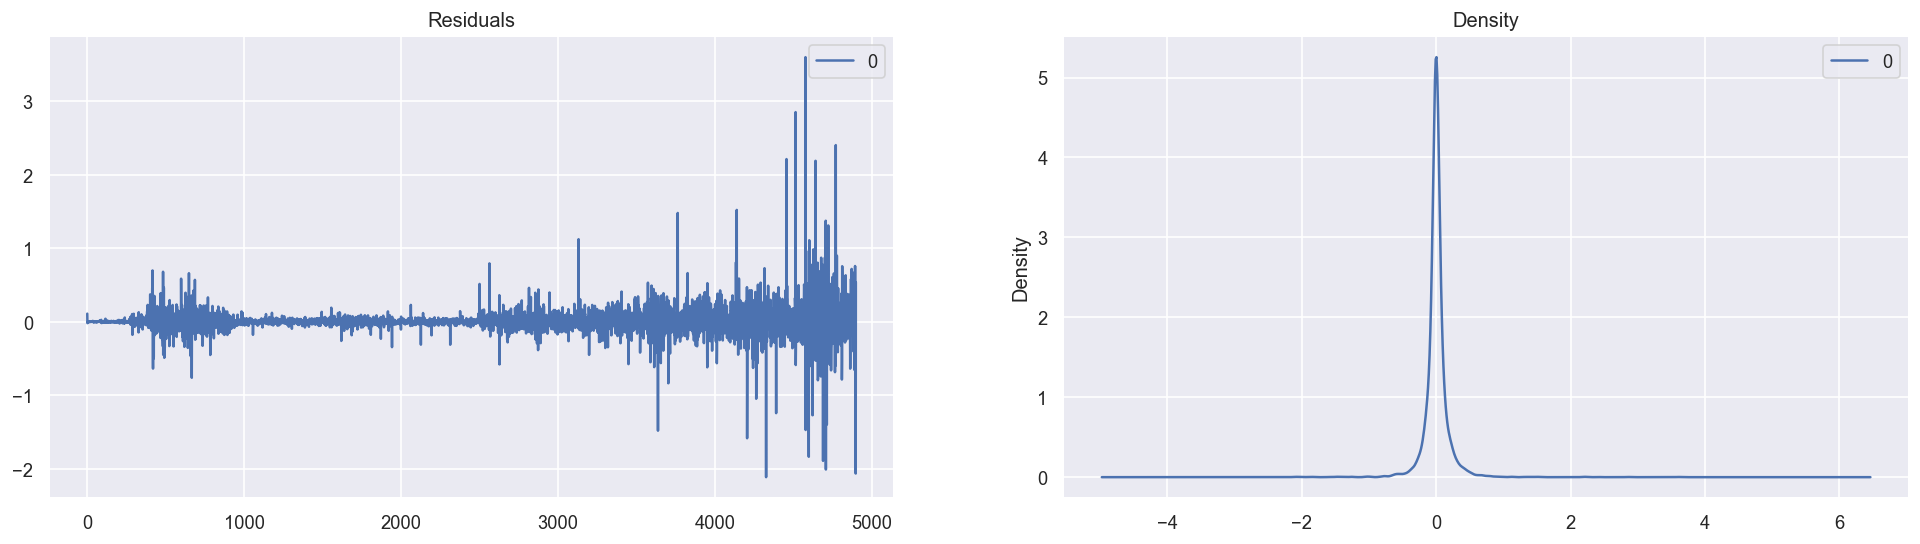

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


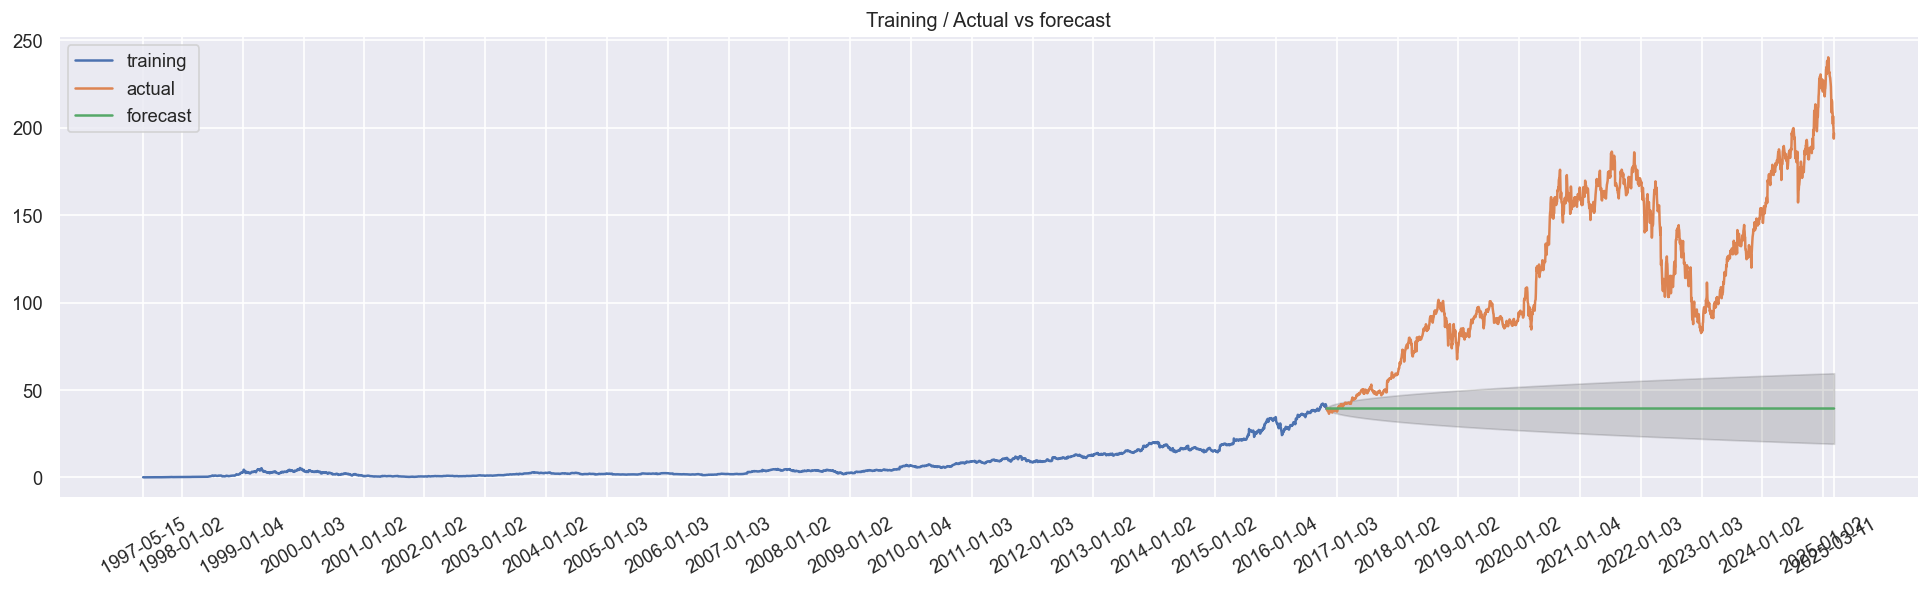

Train / Test based on:
order -> (3, 3, 3)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4899
Model:                 ARIMA(3, 3, 3)   Log Likelihood                1011.240
Date:                Wed, 12 Mar 2025   AIC                          -2008.481
Time:                        02:49:45   BIC                          -1963.007
Sample:                             0   HQIC                         -1992.526
                               - 4899                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8595      0.008   -105.670      0.000      -0.875      -0.844
ar.L2          0.1091      0.010     11.481      0.000       0.090       0.128
ar.L3         -0.0309      0.008     -3.750      0.0

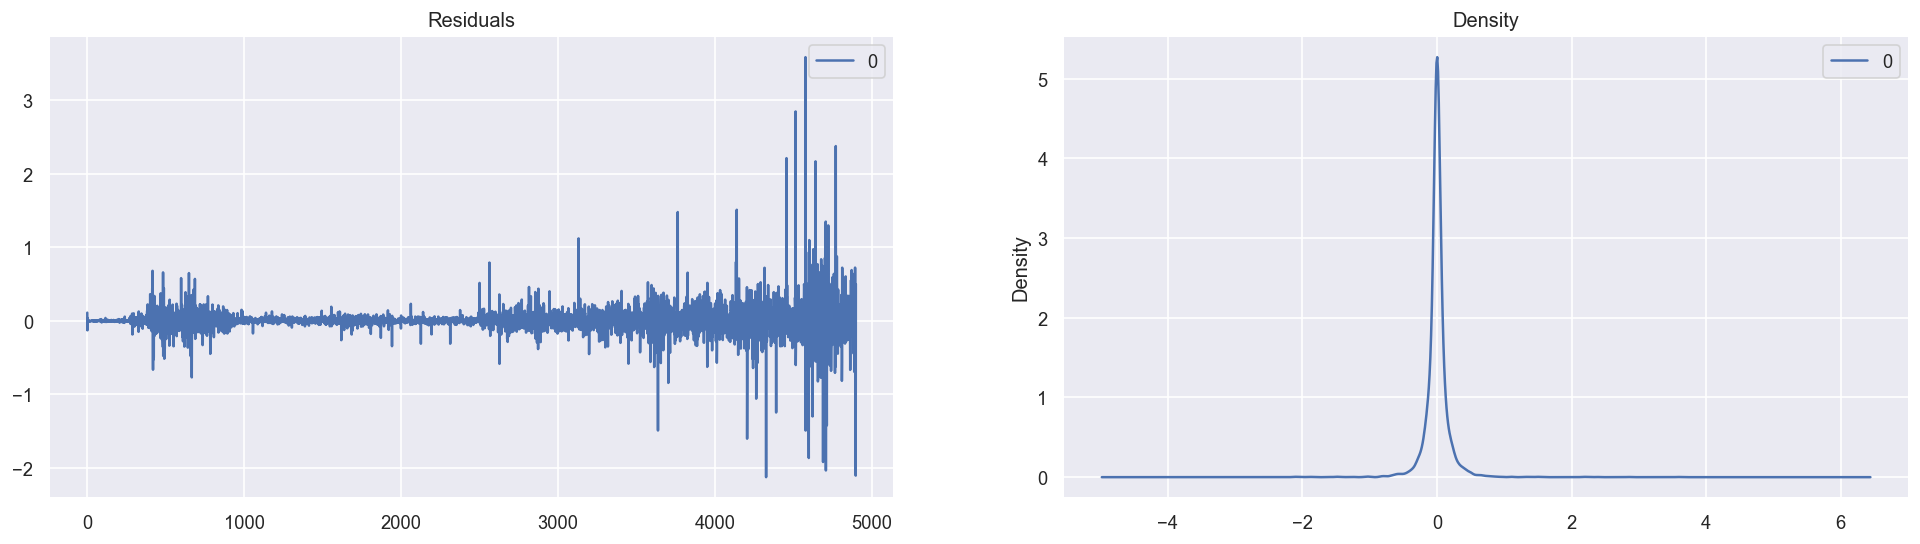

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


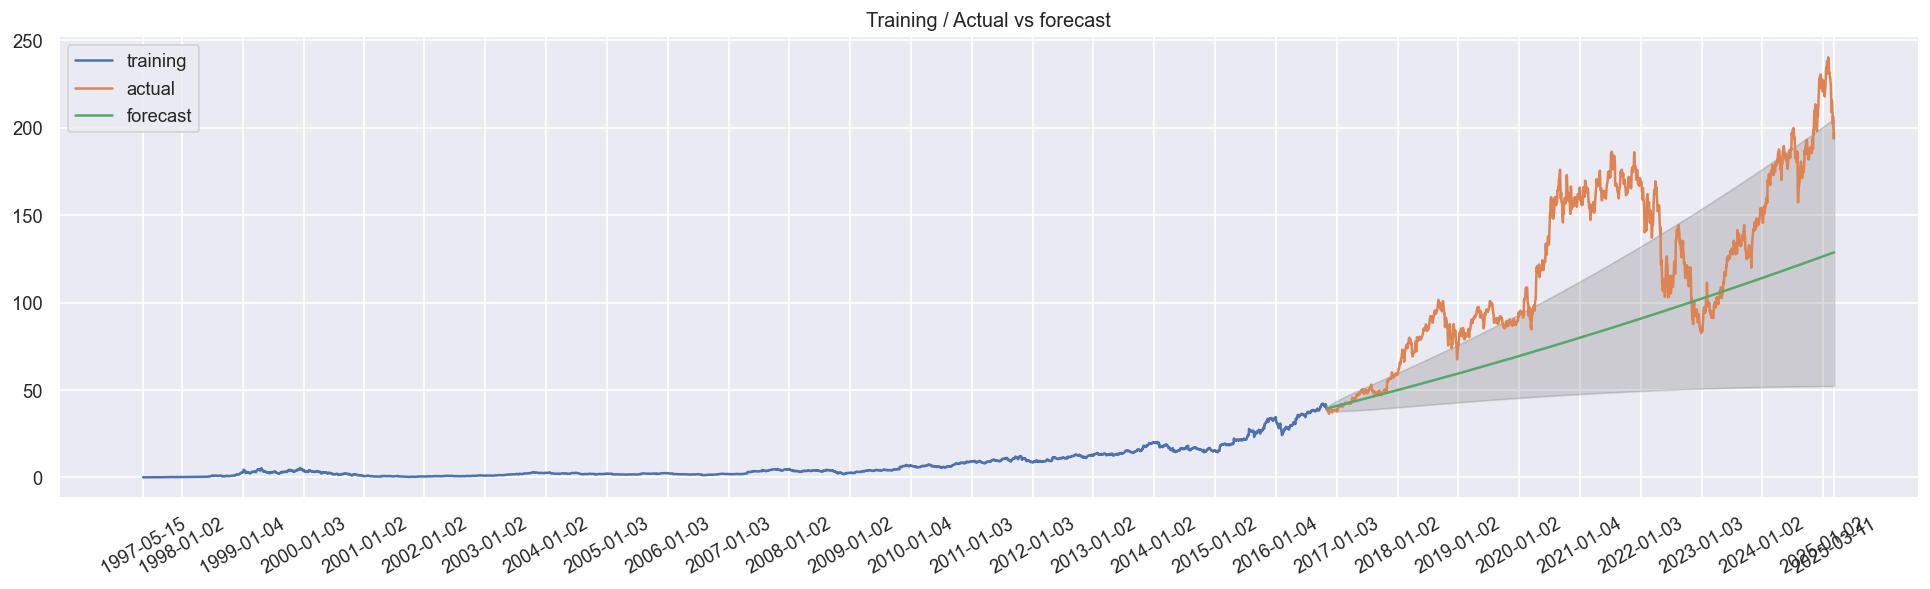

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4899
Model:                 ARIMA(3, 2, 1)   Log Likelihood                1024.828
Date:                Wed, 12 Mar 2025   AIC                          -2039.657
Time:                        02:49:50   BIC                          -2007.175
Sample:                             0   HQIC                         -2028.260
                               - 4899                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1395      0.005     28.657      0.000       0.130       0.149
ar.L2         -0.0253      0.008     -3.107      0.002      -0.041     

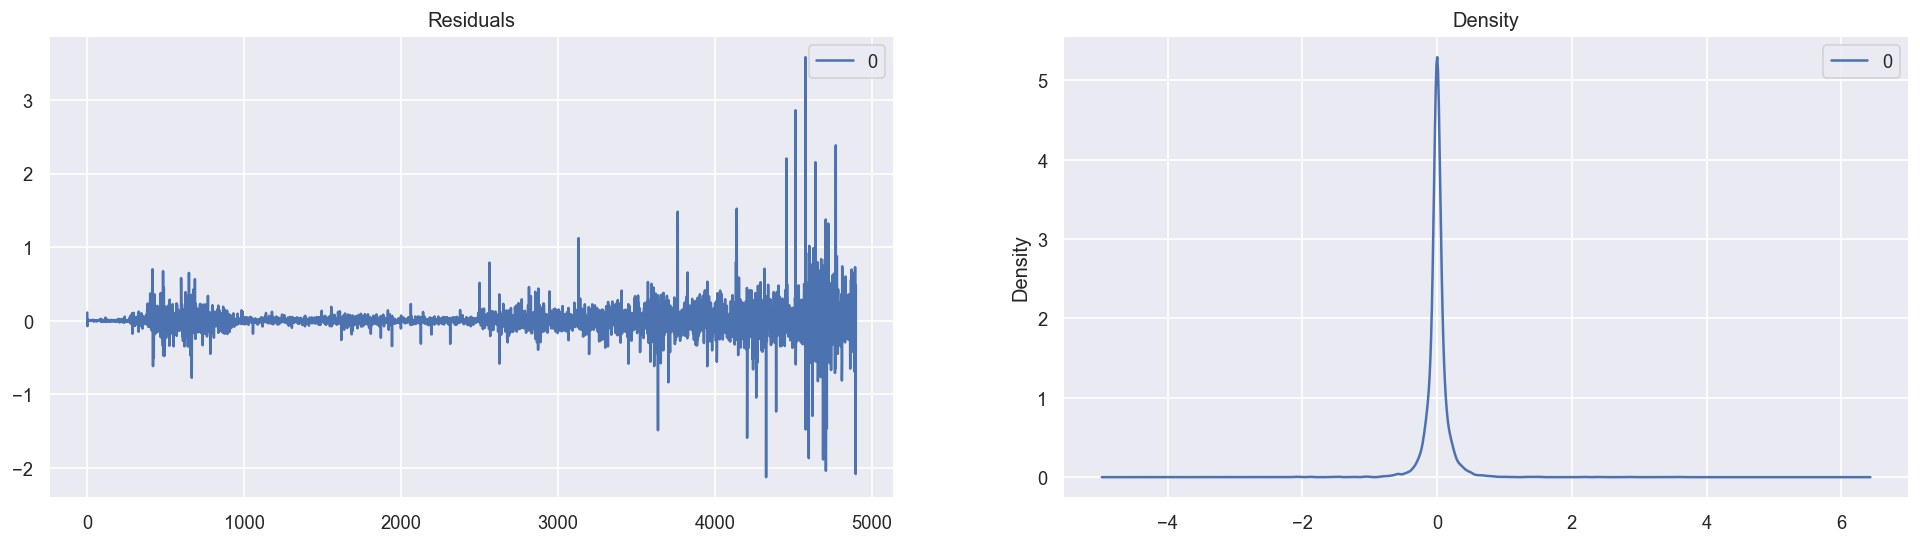

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


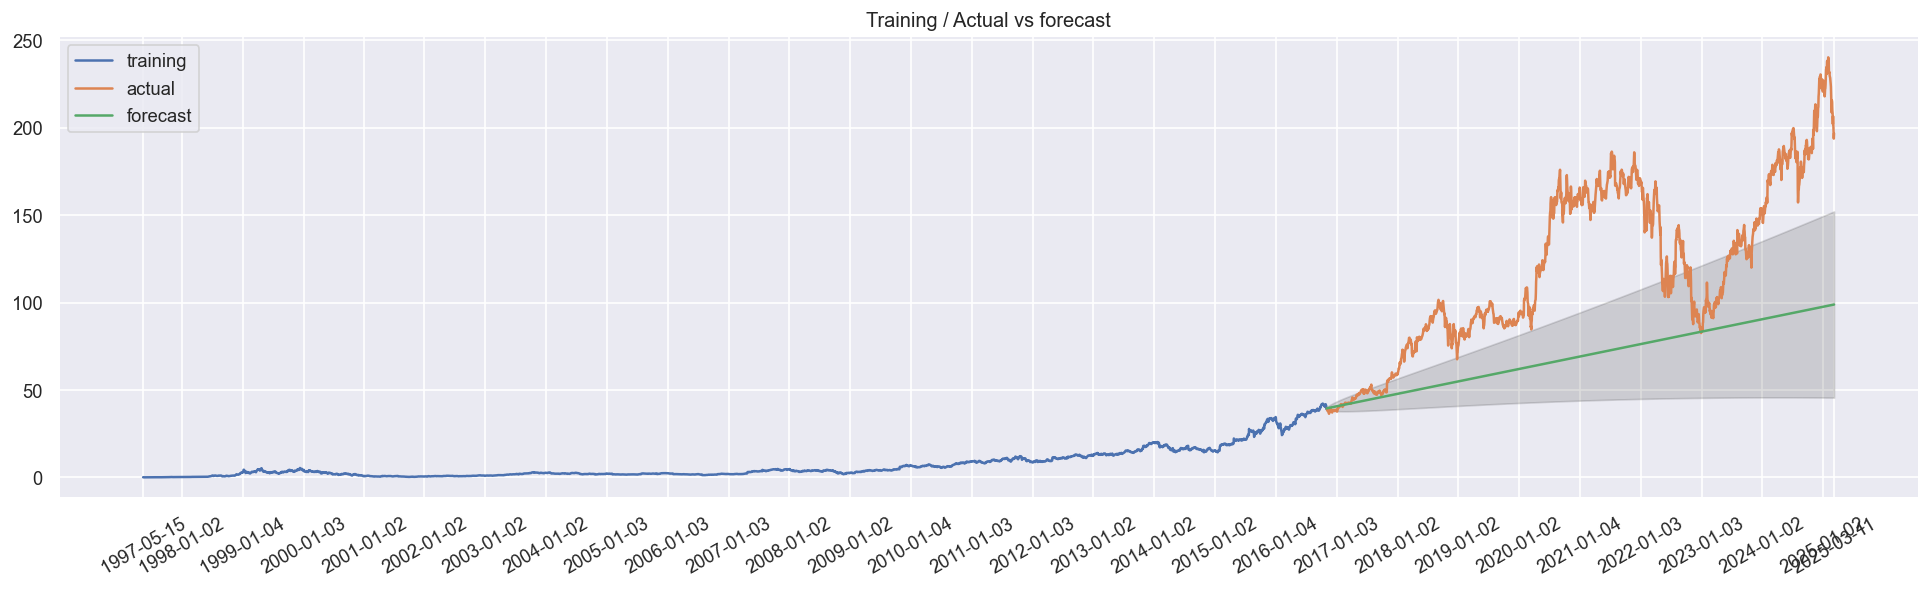

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.8
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5599
Model:                 ARIMA(3, 2, 1)   Log Likelihood               -3409.361
Date:                Wed, 12 Mar 2025   AIC                           6828.721
Time:                        02:49:55   BIC                           6861.871
Sample:                             0   HQIC                          6840.274
                               - 5599                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1711      0.004     46.653      0.000       0.164       0.178
ar.L2         -0.0549      0.004    -13.385      0.000      -0.063     

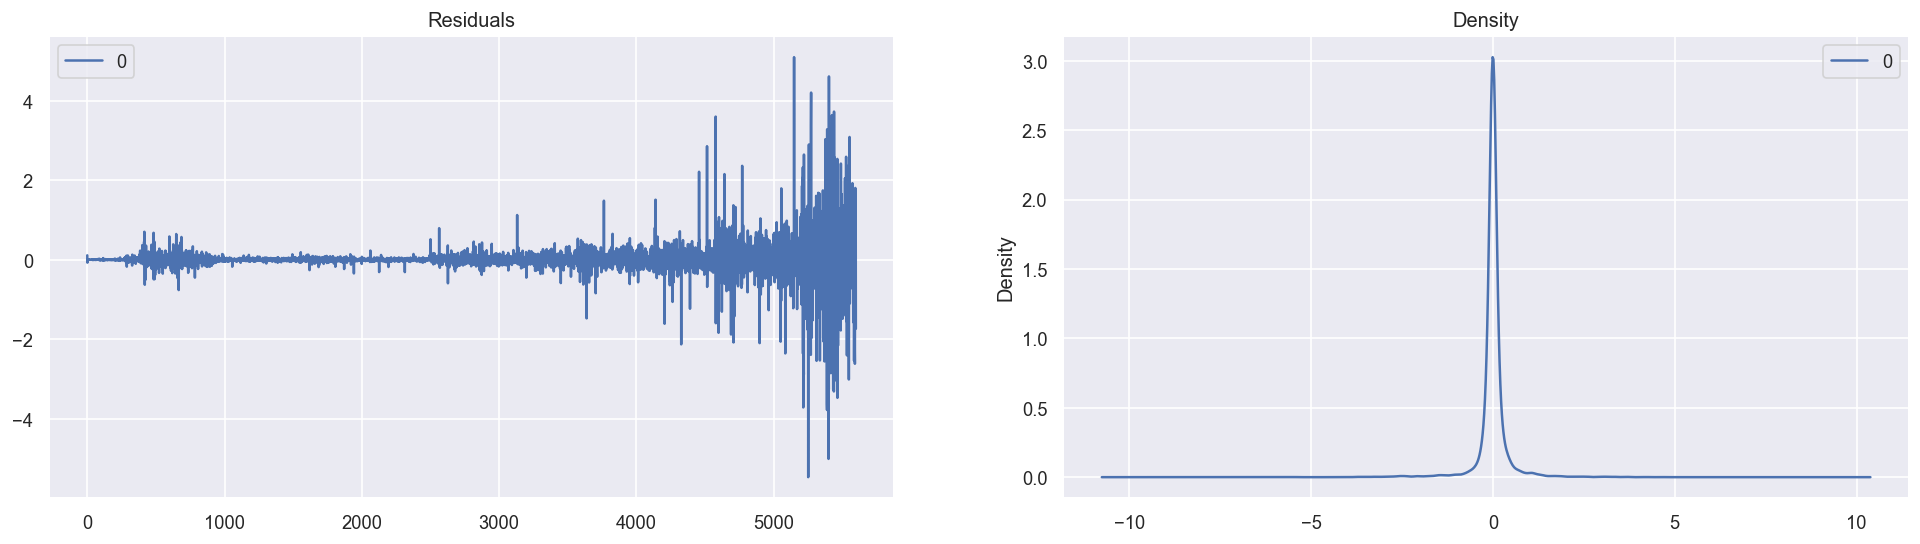

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


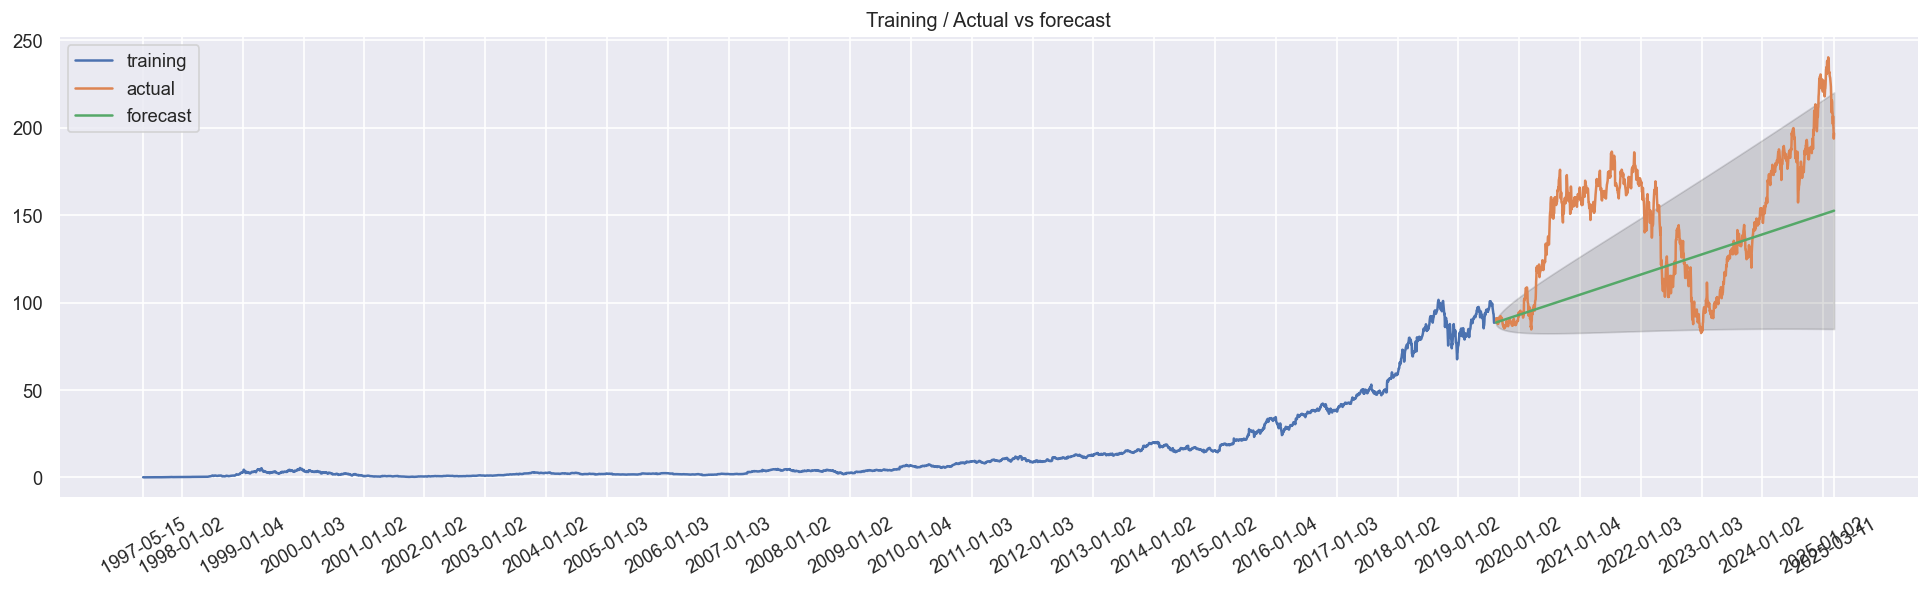

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.9
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 6299
Model:                 ARIMA(3, 2, 1)   Log Likelihood               -8535.884
Date:                Wed, 12 Mar 2025   AIC                          17081.768
Time:                        02:49:59   BIC                          17115.507
Sample:                             0   HQIC                         17093.456
                               - 6299                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1933      0.004     47.856      0.000       0.185       0.201
ar.L2         -0.0798      0.005    -14.863      0.000      -0.090     

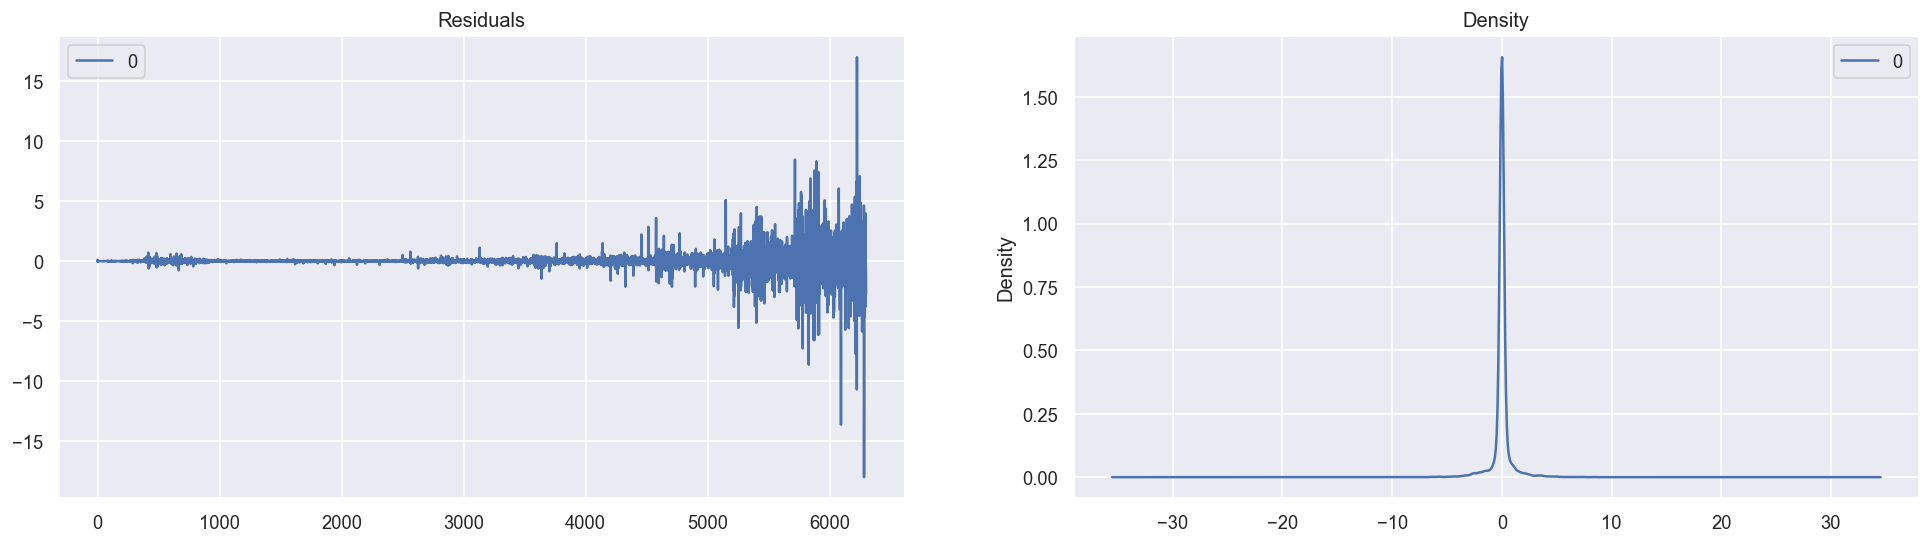

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


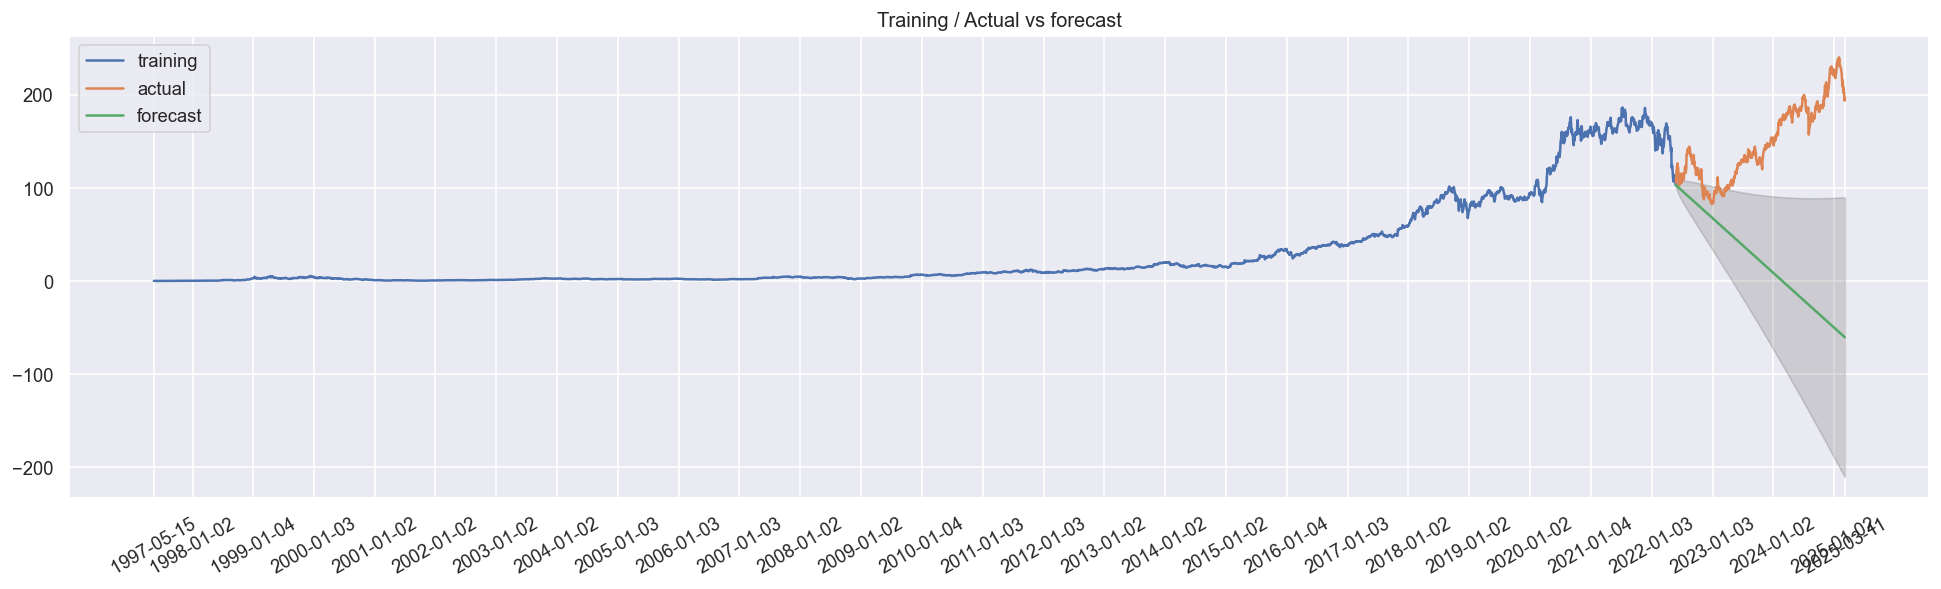

C:\Users\Roey\AppData\Local\Temp\ipykernel_24516\2499829597.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter['year'] = date_filter['date'].str.split('-').str[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_24516\2499829597.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter.loc[0] = dataset.iloc[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_24516\2499829597.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

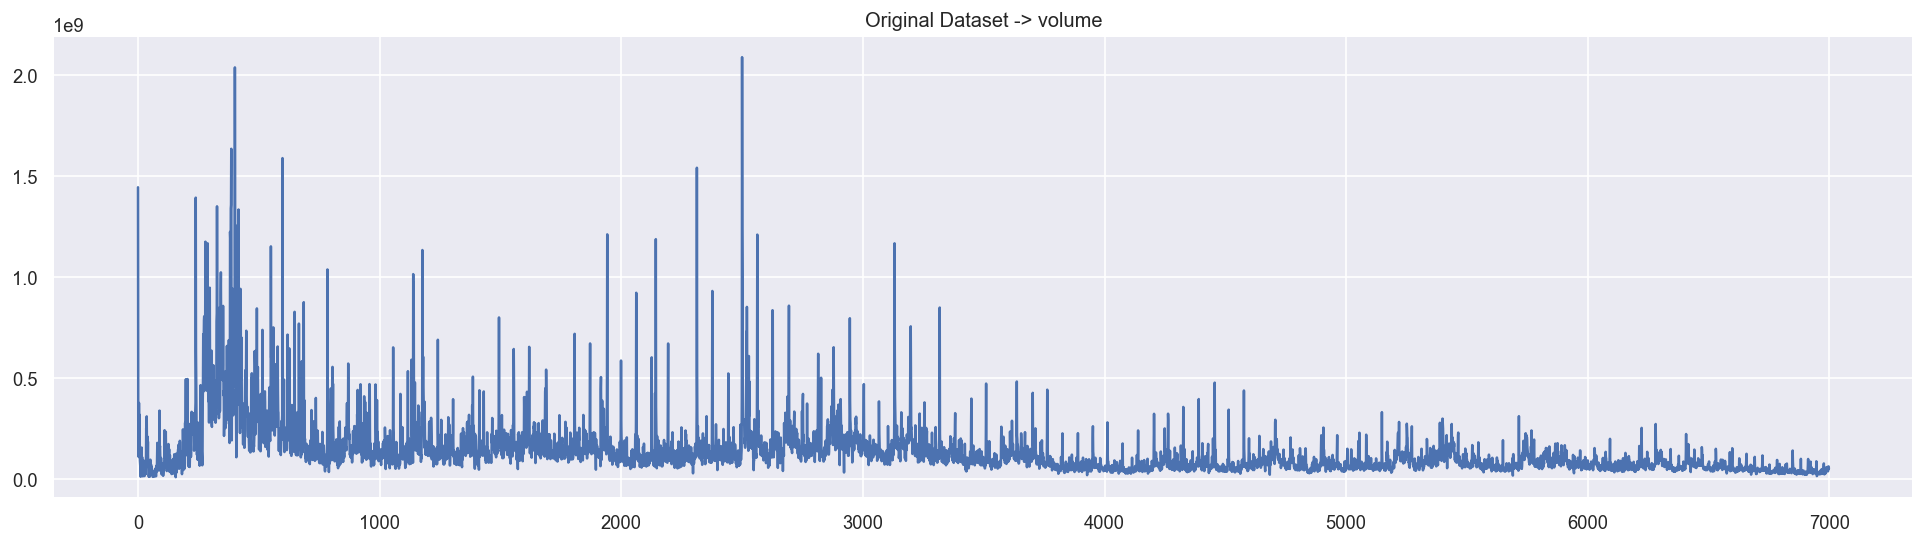

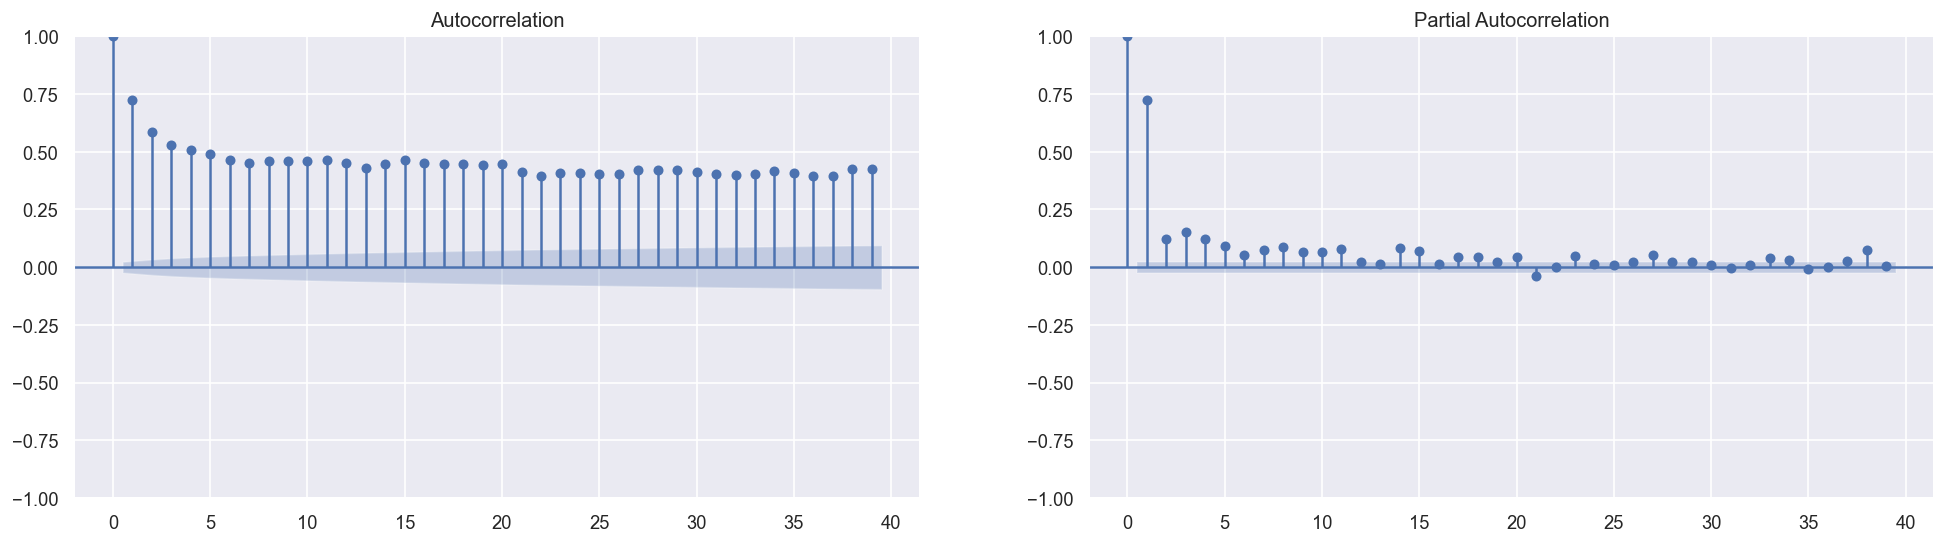

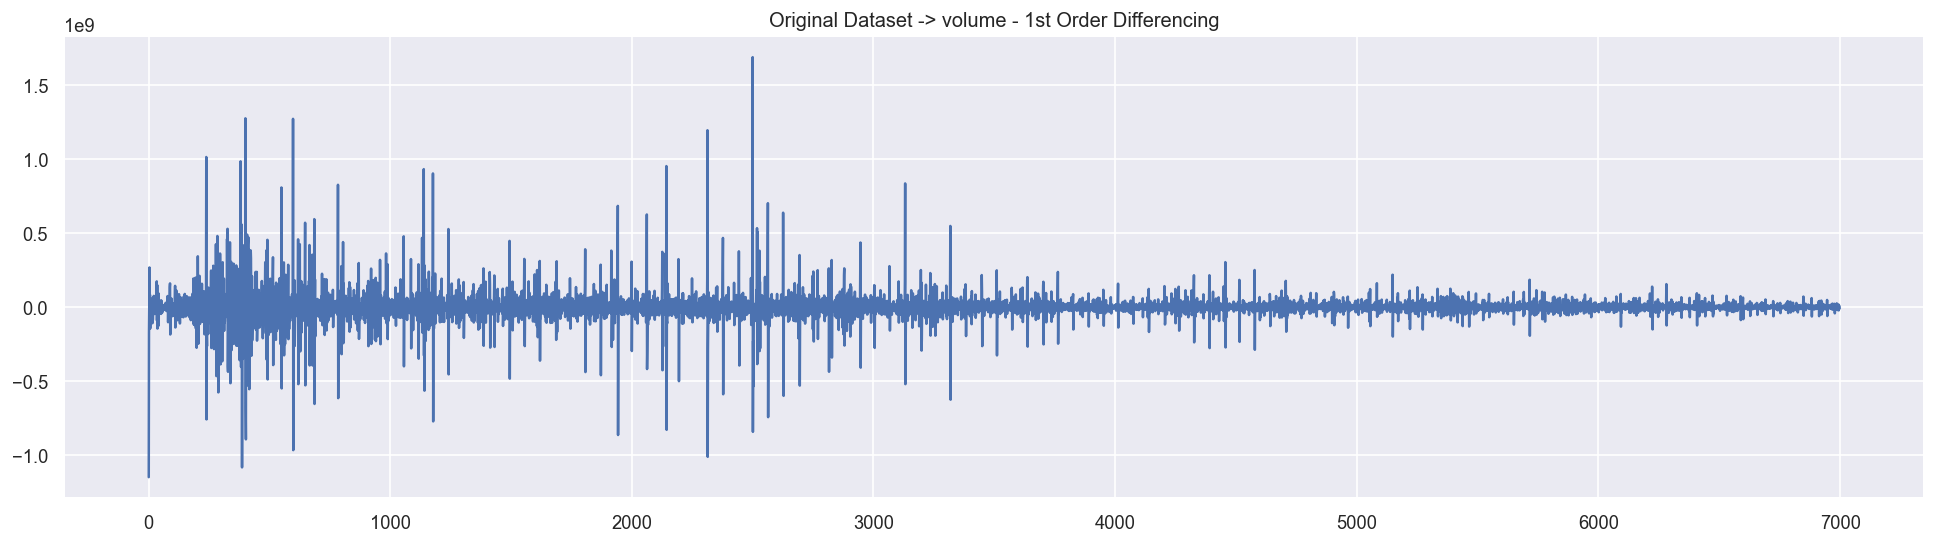

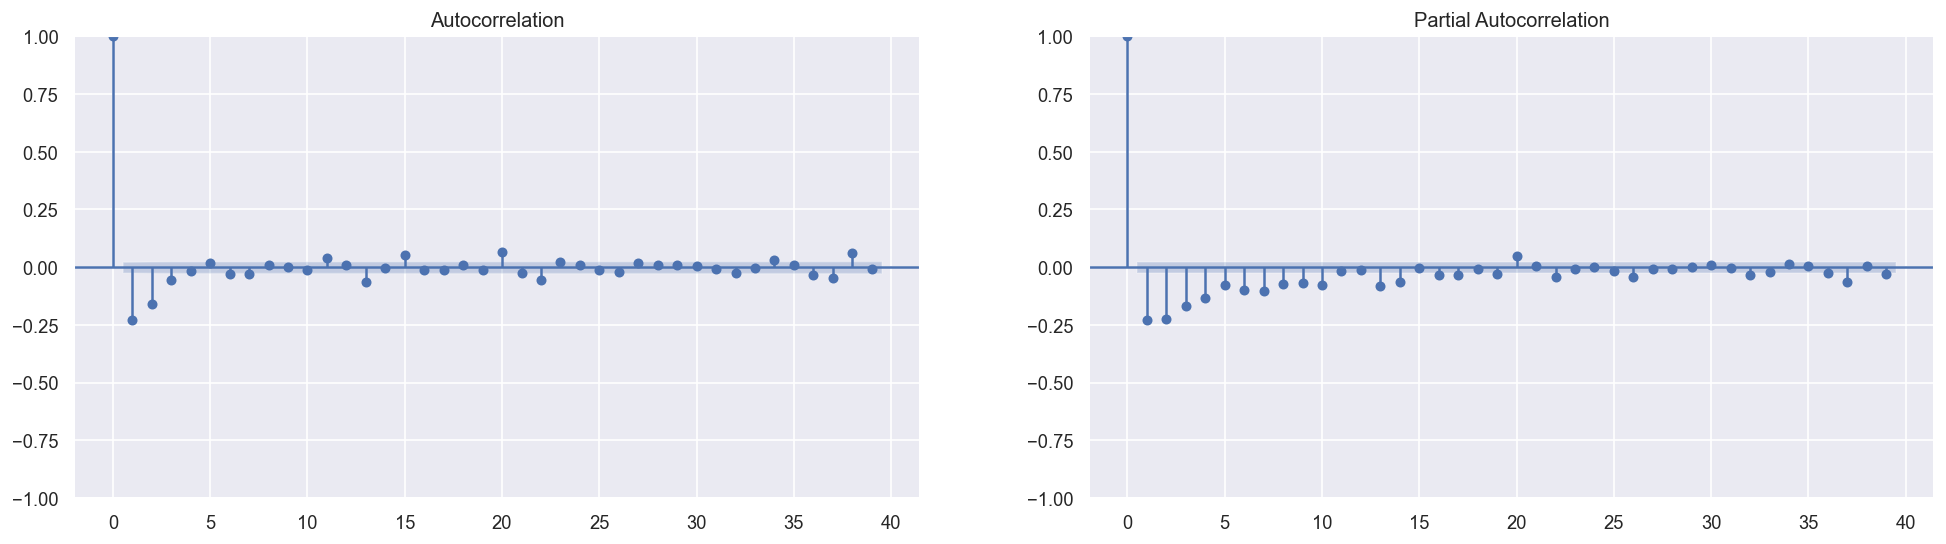

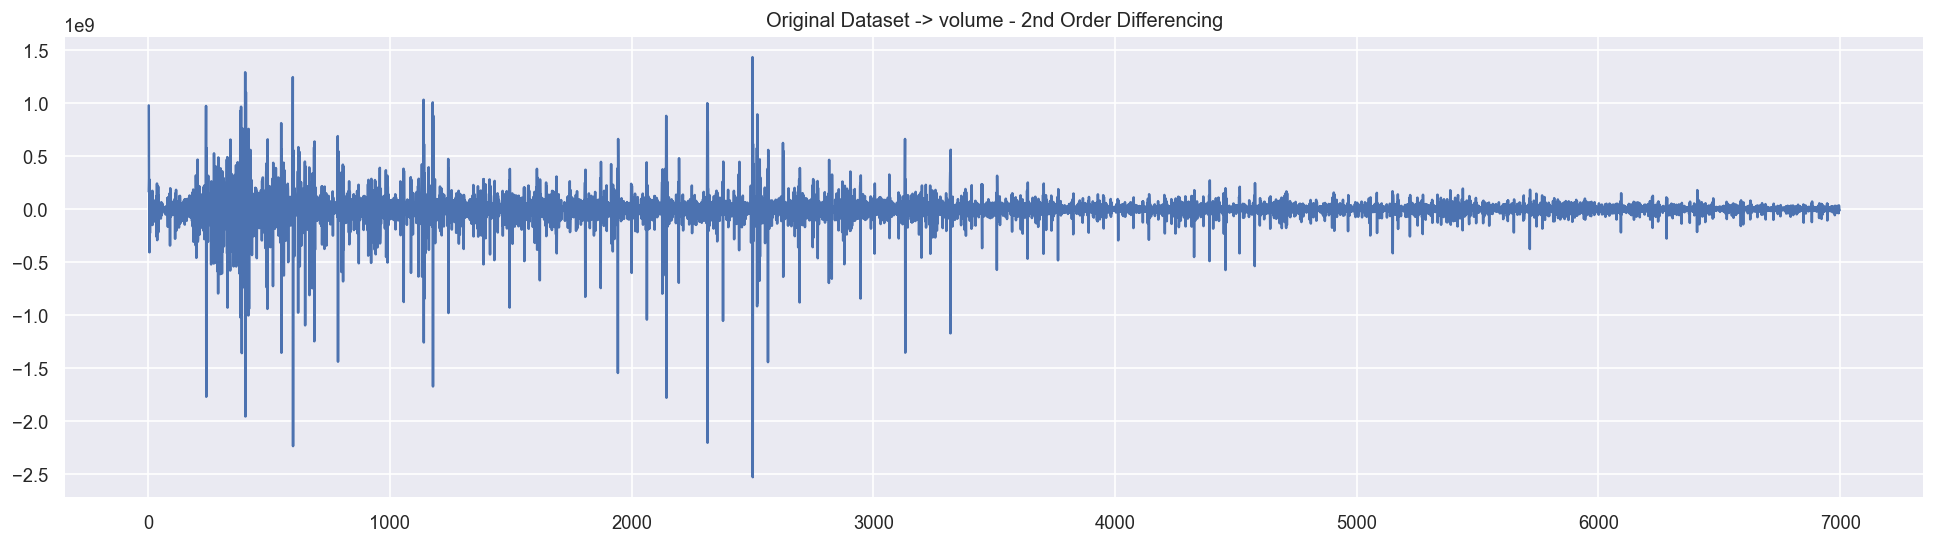

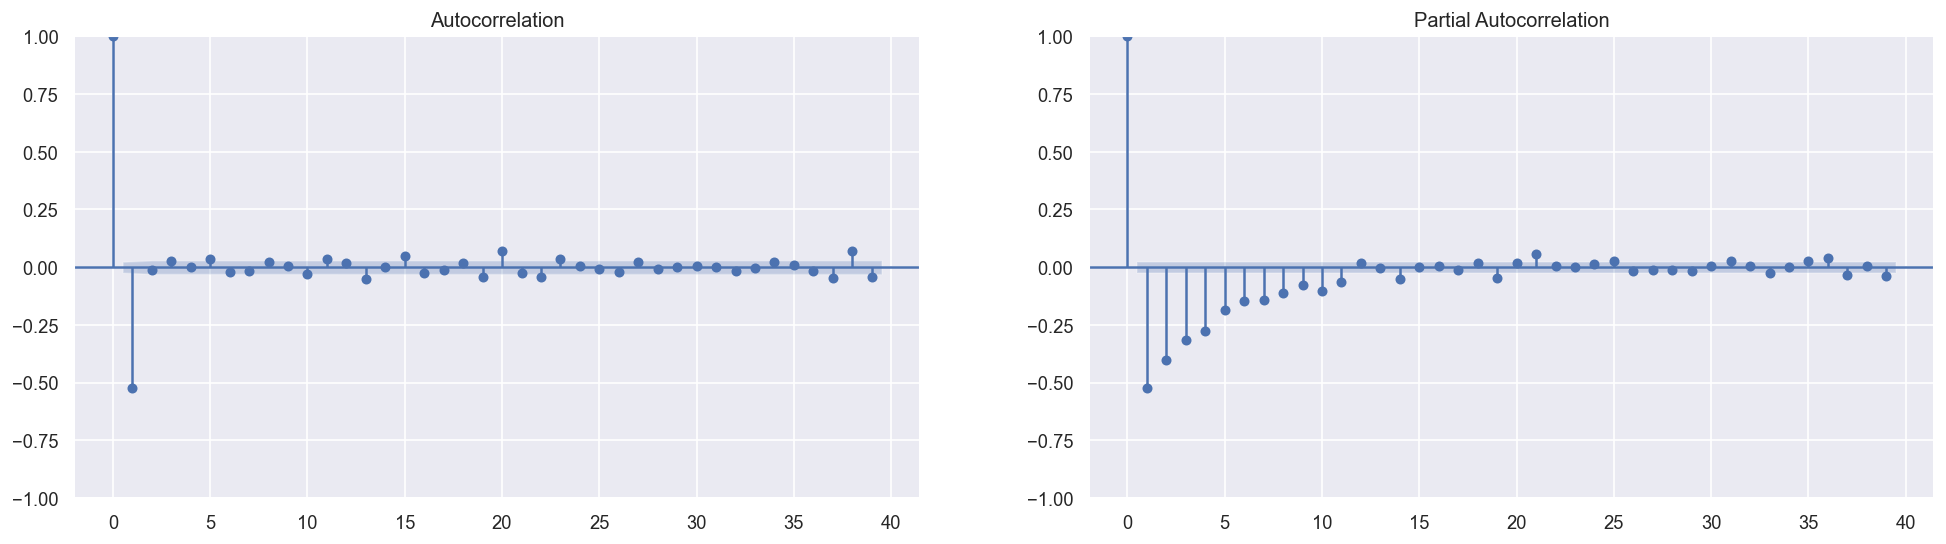

Train / Test based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4899
Model:                 ARIMA(1, 1, 2)   Log Likelihood              -97396.915
Date:                Wed, 12 Mar 2025   AIC                         194801.830
Time:                        02:50:06   BIC                         194827.816
Sample:                             0   HQIC                        194810.947
                               - 4899                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4633      0.016     29.370      0.000       0.432       0.494
ma.L1         -0.9242      0.017    -53.666      0.000      -0.958     

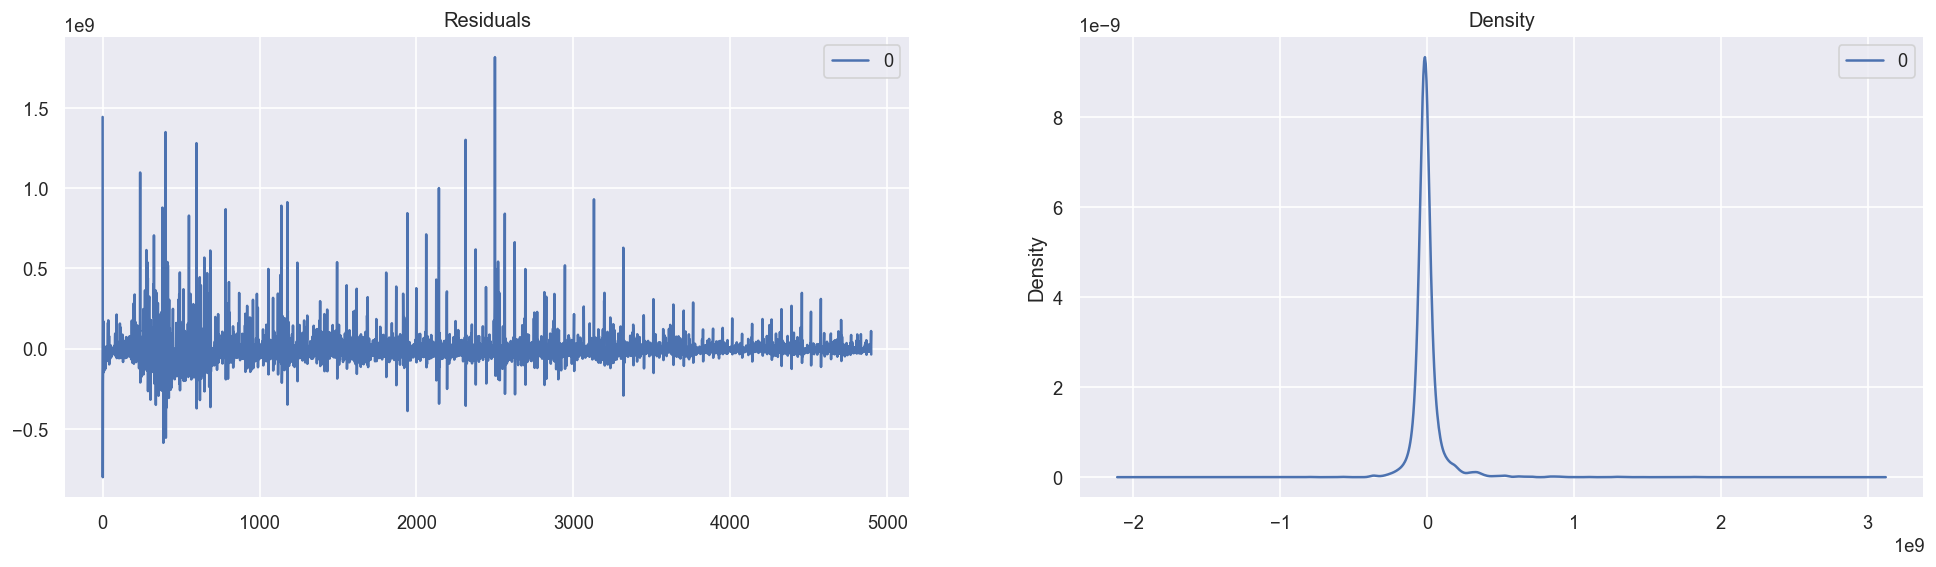

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


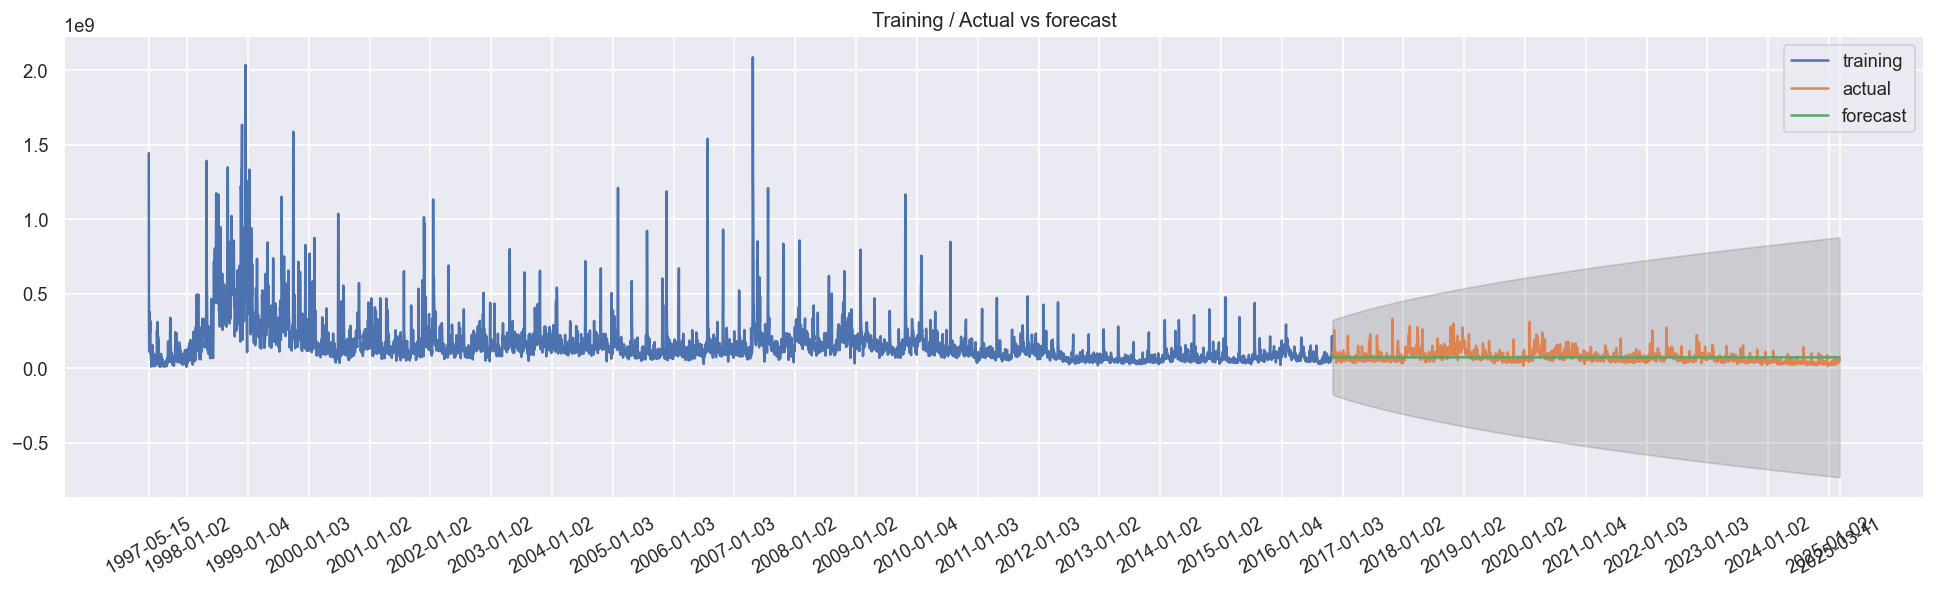

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4899
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -97403.653
Date:                Wed, 12 Mar 2025   AIC                         194813.307
Time:                        02:50:09   BIC                         194832.797
Sample:                             0   HQIC                        194820.145
                               - 4899                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4924      0.007     70.573      0.000       0.479       0.506
ma.L1         -0.9608      0.003   -319.287      0.000      -0.967     

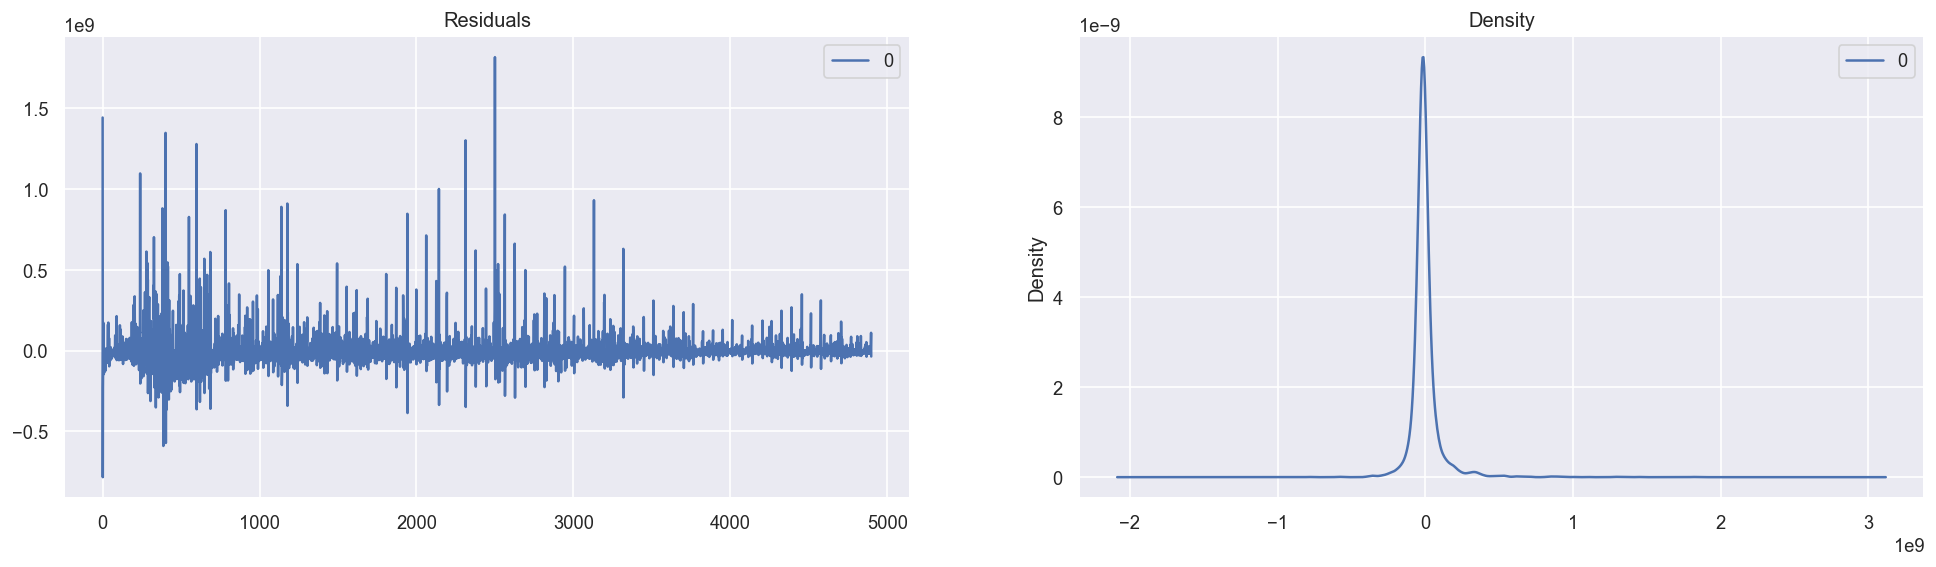

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


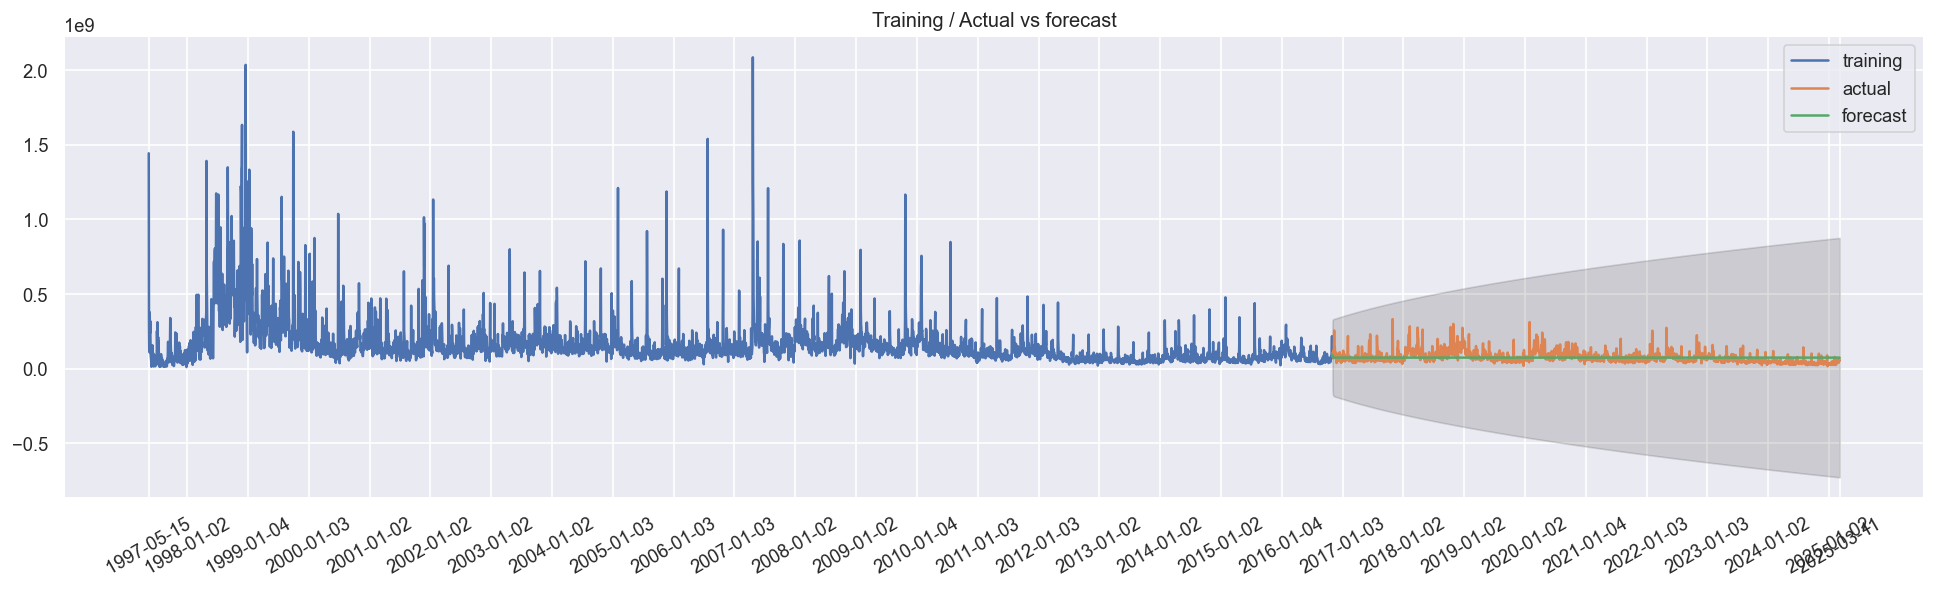

Train / Test based on:
order -> (3, 3, 3)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4899
Model:                 ARIMA(3, 3, 3)   Log Likelihood              -97989.149
Date:                Wed, 12 Mar 2025   AIC                         195992.297
Time:                        02:50:20   BIC                         196037.771
Sample:                             0   HQIC                        196008.252
                               - 4899                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2809      0.009   -136.094      0.000      -1.299      -1.262
ar.L2         -0.5048      0.015    -34.064      0.000      -0.534      -0.476
ar.L3         -0.2235      0.010    -22.312      0.0

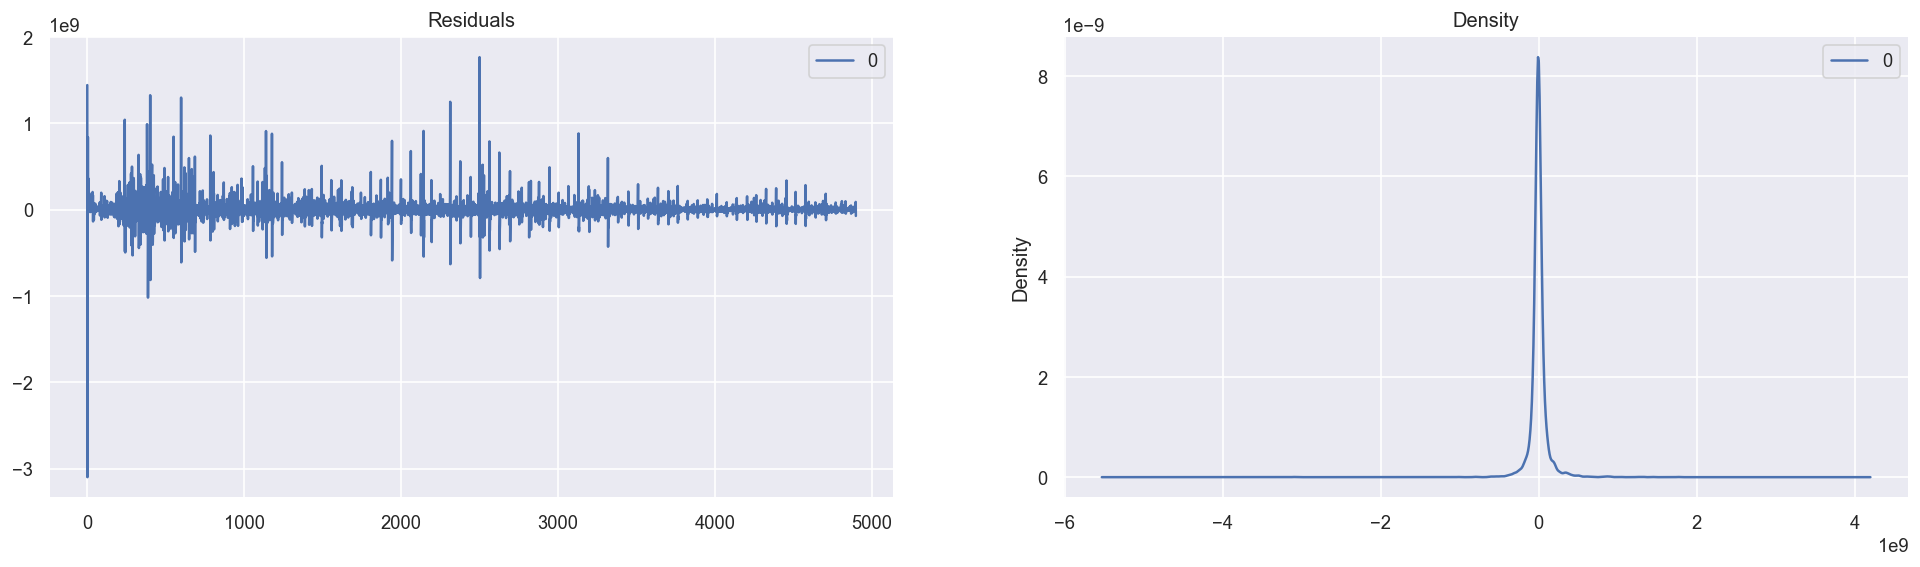

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


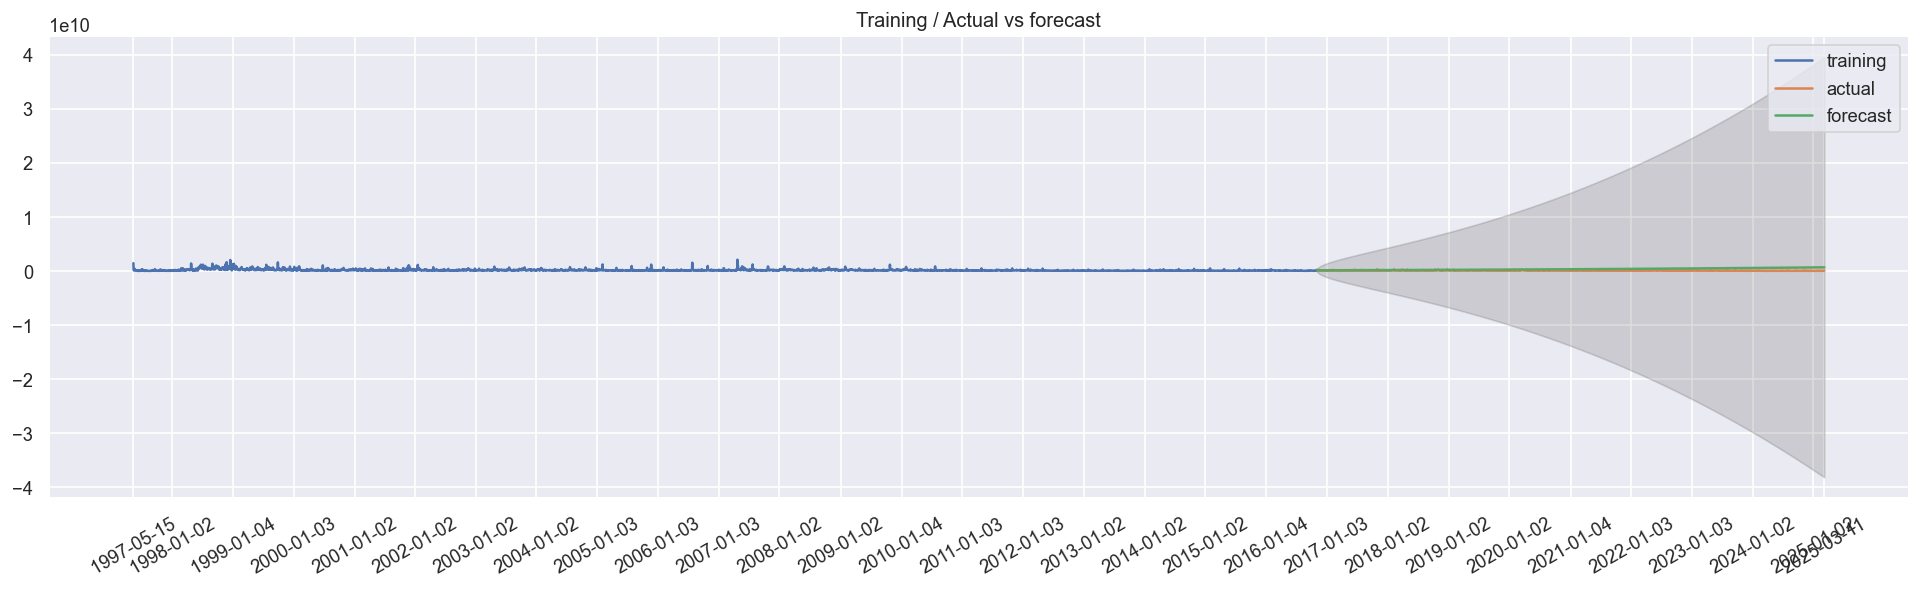

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4899
Model:                 ARIMA(3, 2, 1)   Log Likelihood              -97801.131
Date:                Wed, 12 Mar 2025   AIC                         195612.263
Time:                        02:50:26   BIC                         195644.745
Sample:                             0   HQIC                        195623.659
                               - 4899                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3251      0.008    -41.067      0.000      -0.341      -0.310
ar.L2         -0.2859      0.010    -29.198      0.000      -0.305     

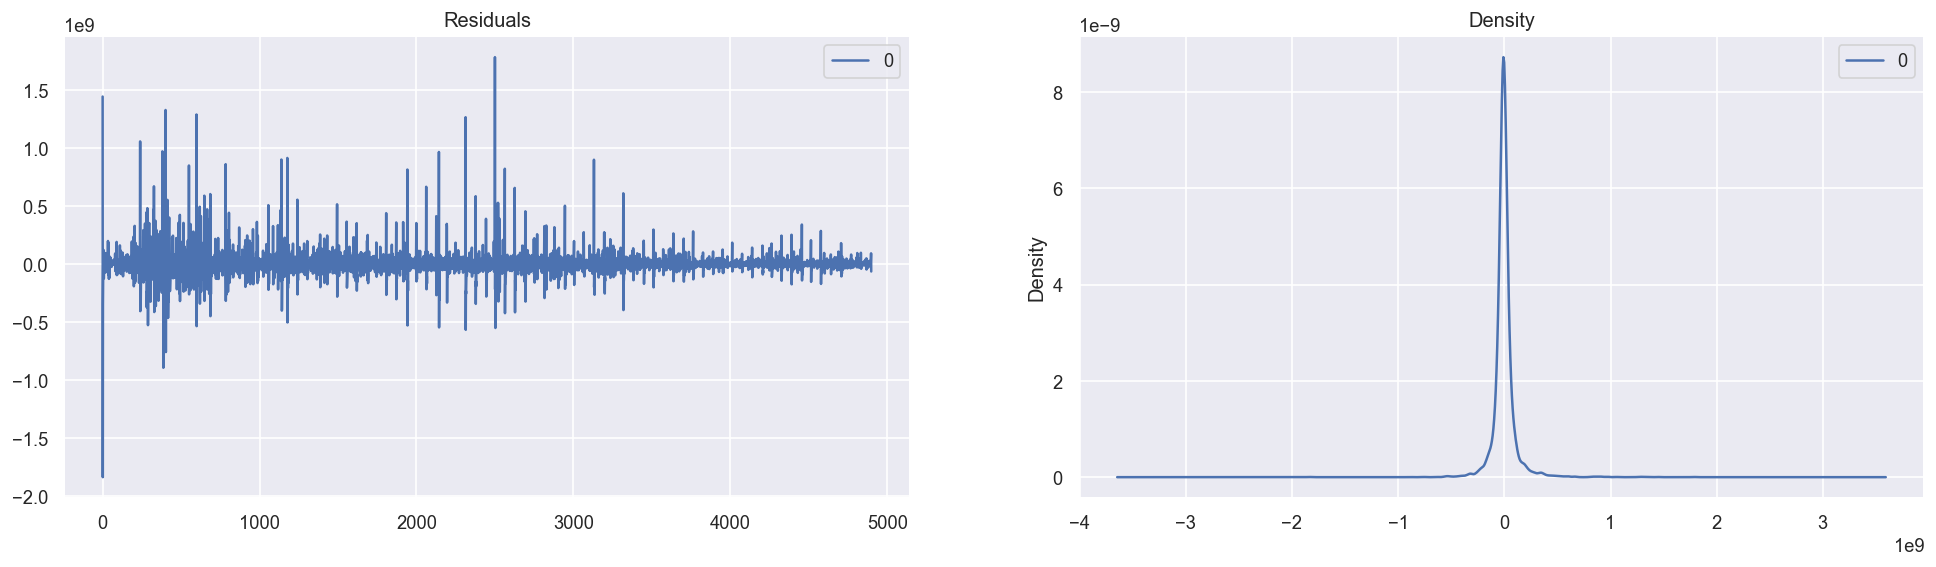

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


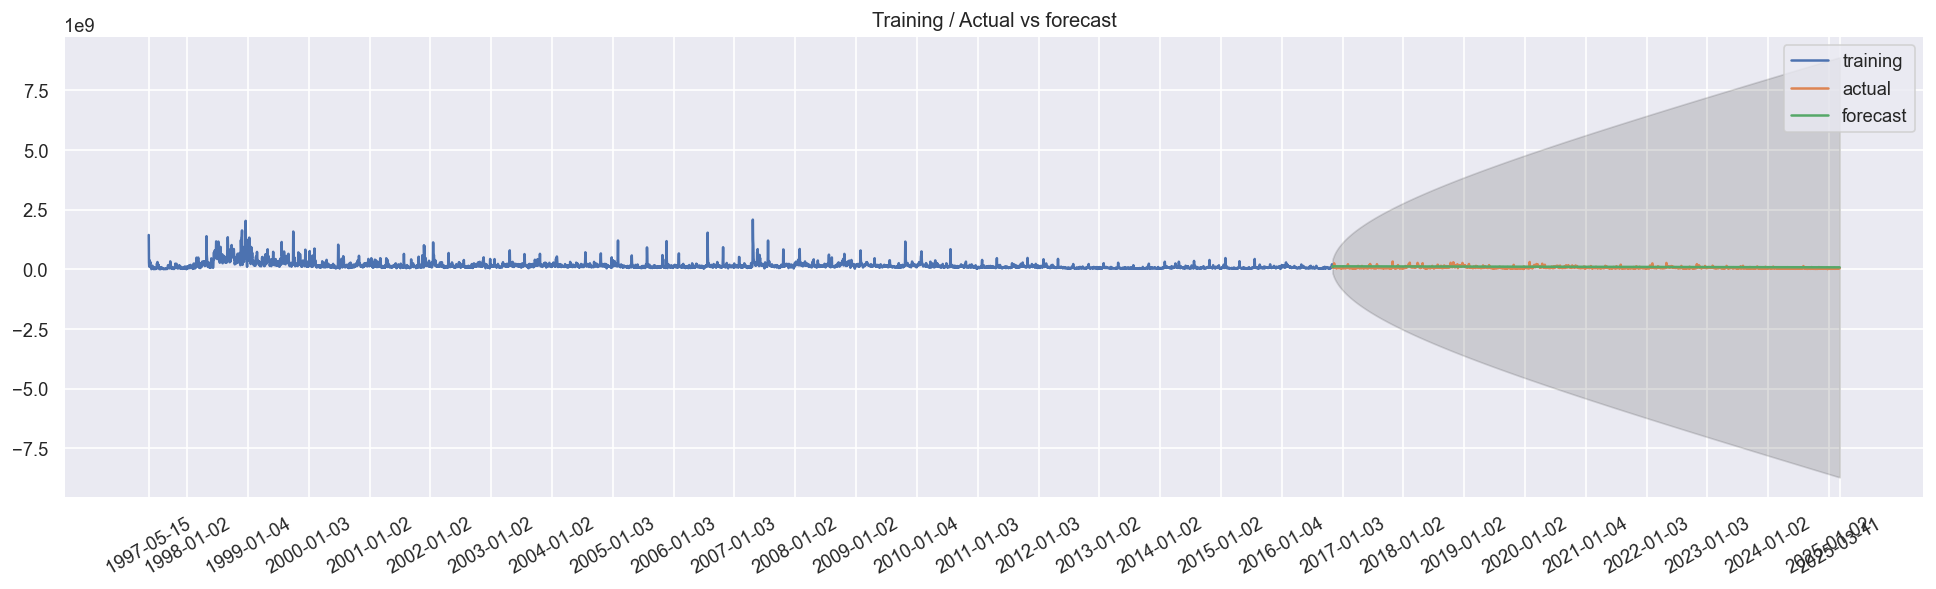

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.8
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5599
Model:                 ARIMA(3, 2, 1)   Log Likelihood             -111442.695
Date:                Wed, 12 Mar 2025   AIC                         222895.390
Time:                        02:50:32   BIC                         222928.540
Sample:                             0   HQIC                        222906.943
                               - 5599                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3246      0.007    -46.315      0.000      -0.338      -0.311
ar.L2         -0.2856      0.009    -32.951      0.000      -0.303     

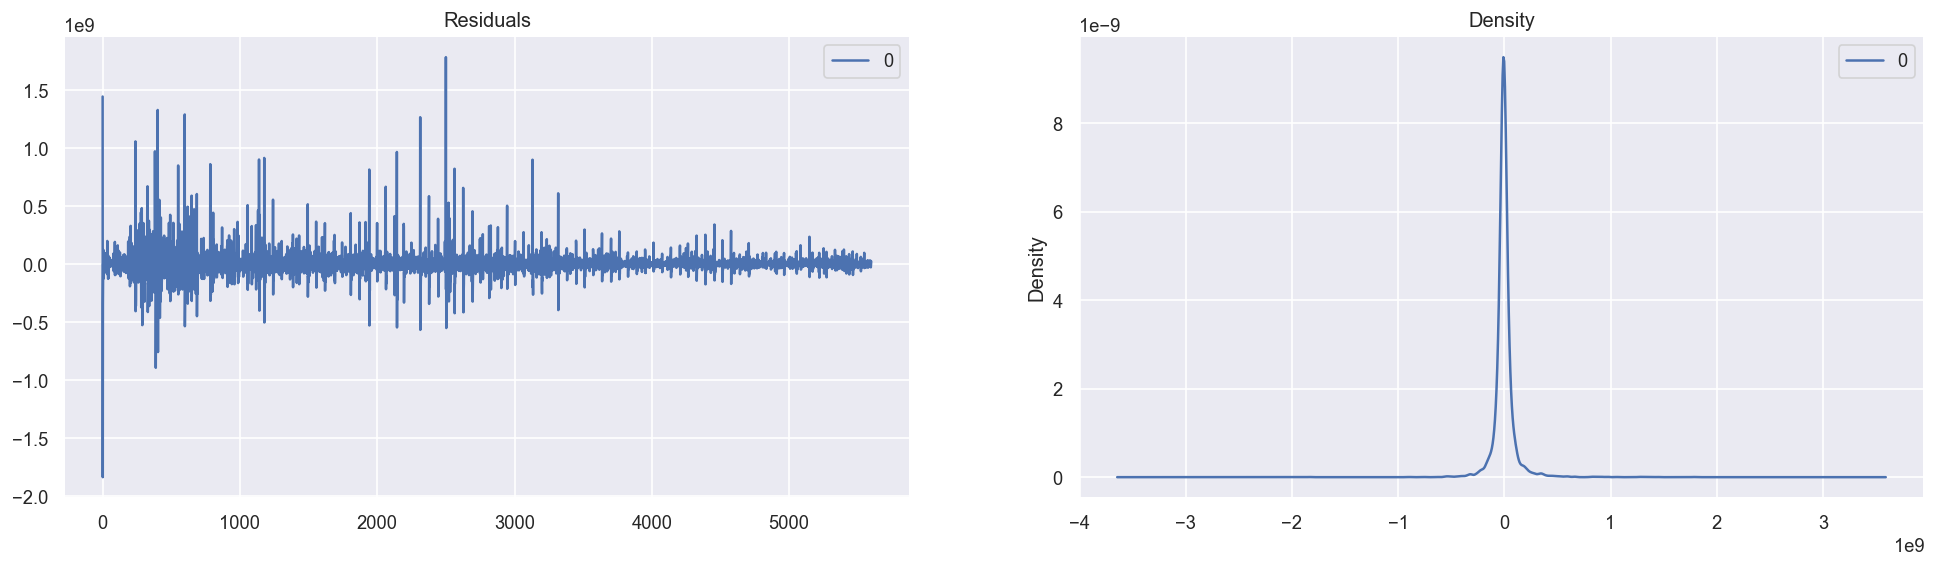

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


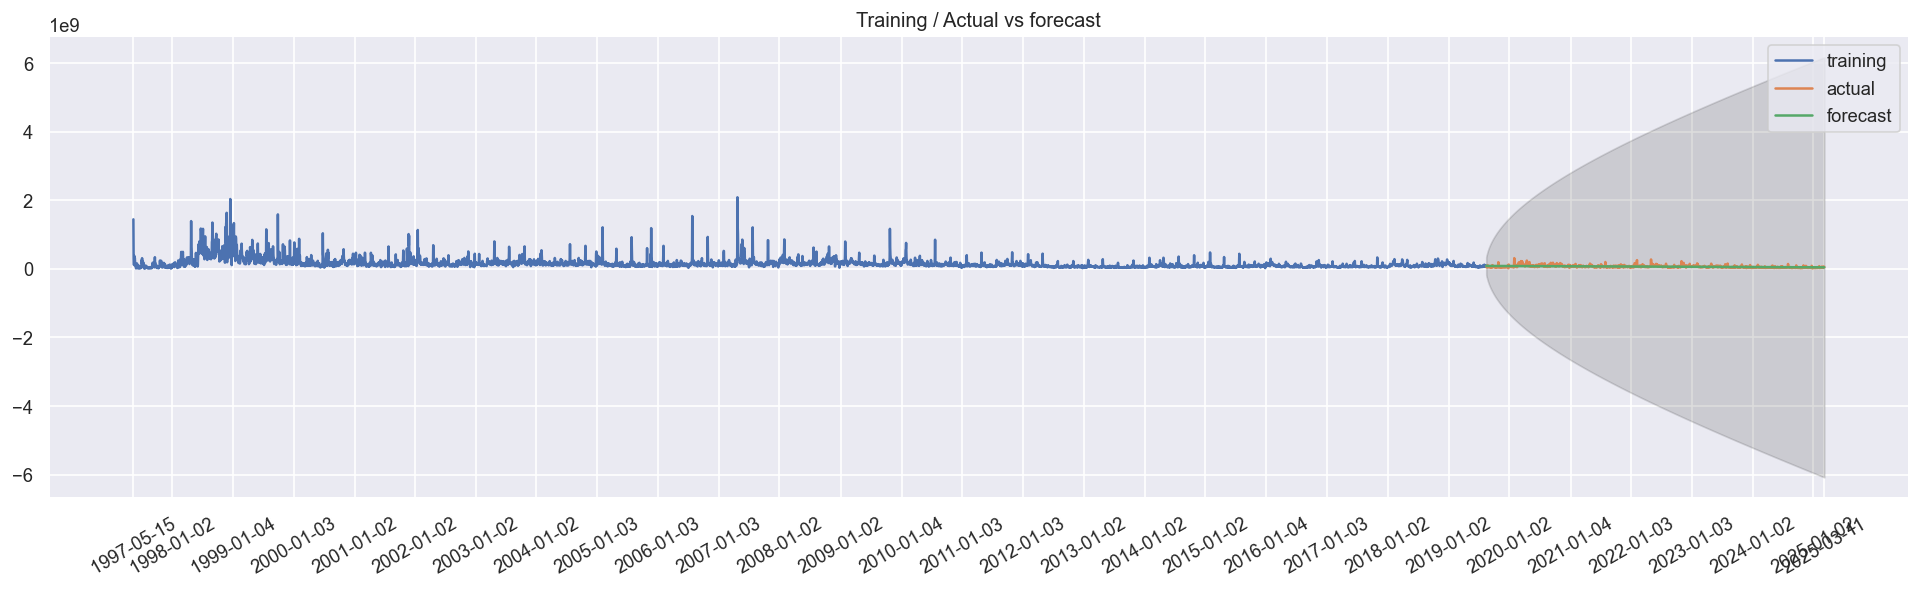

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.9
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 6299
Model:                 ARIMA(3, 2, 1)   Log Likelihood             -125039.014
Date:                Wed, 12 Mar 2025   AIC                         250088.028
Time:                        02:50:38   BIC                         250121.767
Sample:                             0   HQIC                        250099.716
                               - 6299                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3246      0.006    -51.585      0.000      -0.337      -0.312
ar.L2         -0.2859      0.008    -36.761      0.000      -0.301     

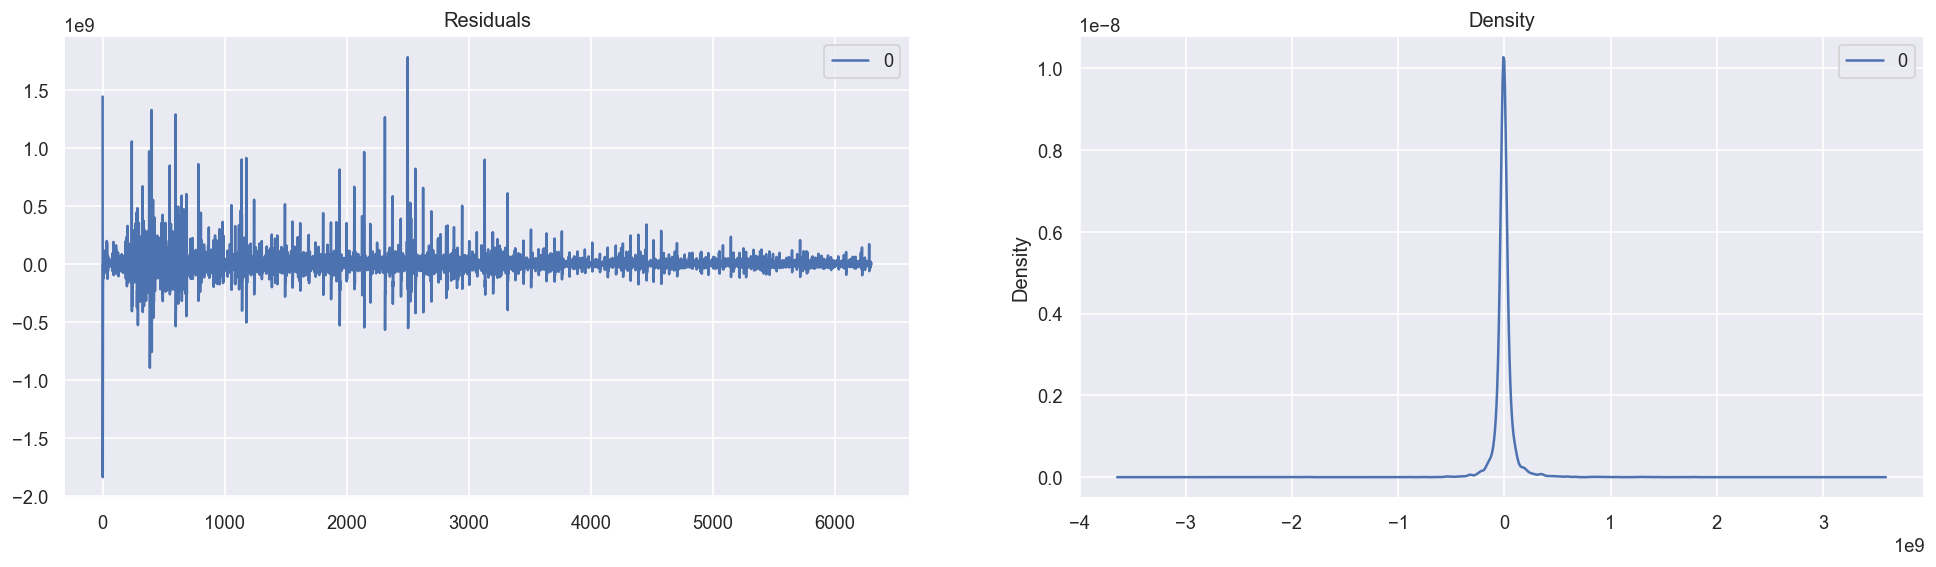

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


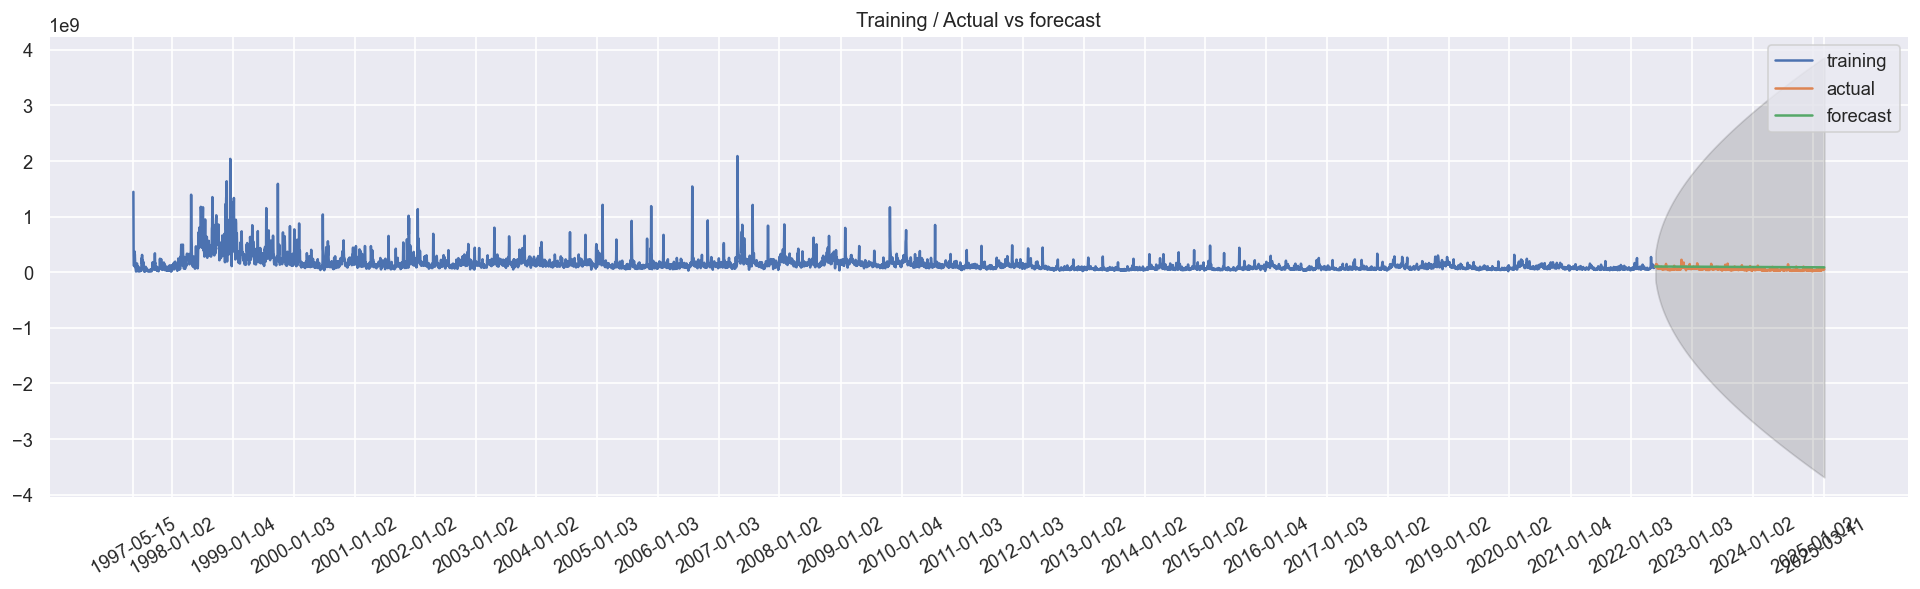

In [ ]:
hyperparams = [{
    "order": (1, 1, 2),
    "train_rate": 0.7
},{
    "order": (1, 1, 1),
    "train_rate": 0.7
},{
    "order": (3, 3, 3),
     "train_rate": 0.7
},{
    "order": (3, 2 ,1),
     "train_rate": 0.7
},{
    "order": (3, 2 ,1),
     "train_rate": 0.8
},{
    "order": (3, 2 ,1),
     "train_rate": 0.9
}]

for dataset_type, dataset in datasets.items():
    date_labels = get_date_labels_amzn(dataset)

    #print(date_labels)
    
    plot_acf(dataset.value, f"Original Dataset -> {dataset_type}")
    print("==================================================================================================")
    for idx, hyperparam in enumerate(hyperparams):
        predicted_dataset = run_arima_train_test(dataset, hyperparam, date_labels)
        print("==================================================================================================")

# Use of generative AI

Please use the cell below to describe your use of generative AI in this assignment.
